<a href="https://colab.research.google.com/github/tyhardison/Research-Project-Do-LLMs-Play-Nash/blob/main/Final_Project_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Do LLMs Play Nash?**
# ***Final Project - Part 2***


---

**Name: Ty Hardison**

**Course: CSCE 361**

# 1) **Analysis Setup**


---




# 1.1) Data Retrieval


This code will seek the following csv files in the folder ***LLM_Nash_Experiment*** contained in the user's Google Drive:

  * ***Claude-Haiku-5.2.csv***
  * ***gpt-5.5.csv***
  * ***gemini-2.5-flash-lite.csv***
  * ***Claude-Sonnet-4.5.csv***
  * ***gpt-o4-mini.csv***
  * ***gemini-2.5-flash.csv***
  * ***Claude-Haiku-5.2_Reasoning.csv***
  * ***gpt-5.5_Reasoning.csv***
  * ***gemini-2.5-flash-lite_Reasoning.csv***
  * ***Claude-Sonnet-4.5_Reasoning.csv***
  * ***gpt-o4-mini_Reasoning.csv***
  * ***gemini-2.5-flash_Reasoning.csv***

Experiment files have been provided, but they can be replicated by running the code in part one through chat.tamu.ai and selecting the appropriate model/tokens. You must rename the file upon download and save to your Google Drive.

In [ ]:
# ============================================================
#  Do LLMs Play Nash? — Analysis Notebook
#  CSCE 631 — Algorithmic Game Theory meets LLMs
# ============================================================
# Run cells top to bottom after data collection is complete.
# ============================================================

# ── Installs ─────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scipy --quiet

# ── Imports ──────────────────────────────────────────
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chisquare, entropy
from typing import Dict, List, Optional, Tuple
warnings.filterwarnings("ignore")

# ── File Registry ────────────────────────────────────
# To add Gemini Flash when ready: uncomment the two lines marked ← uncomment
# Nothing else needs to change — all downstream code reads from these lists.

# ── Mount Google Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/LLM_Nash_Experiment/"   # update if needed

# ── Model registry ────────────────────────────────────────────
# Each entry maps a CSV filename to model metadata.
# thinking=True  → model uses internal reasoning (Sonnet, o4-mini, Gemini Flash)
# thinking=False → model responds directly (Haiku, GPT-5.5, Gemini Flash Lite)

MODEL_FILES = [
    # Non-thinking models
    {"file": "Claude-Haiku-5.2.csv",               "model": "Claude-Haiku-5.2",      "thinking": False, "family": "Claude"},
    {"file": "gpt-5.5.csv",                        "model": "gpt-5.5",               "thinking": False, "family": "OpenAI"},
    {"file": "gemini-2.5-flash-lite.csv",          "model": "gemini-2.5-flash-lite", "thinking": False, "family": "Google"},
    # Thinking models
    {"file": "Claude-Sonnet-4.5.csv",              "model": "Claude Sonnet 4.5",     "thinking": True,  "family": "Claude"},
    {"file": "gpt-o4-mini.csv",                    "model": "o4-mini",               "thinking": True,  "family": "OpenAI"},
    {"file": "gemini-2.5-flash.csv",             "model": "gemini-2.5-flash",          "thinking": True,  "family": "Google"},  # ← uncomment when ready
]

REASONING_FILES = [
    # Non-thinking models
    {"file": "Claude-Haiku-5.2_reasoning.csv",      "model": "Claude-Haiku-5.2",      "thinking": False, "family": "Claude"},
    {"file": "gpt-5.5_reasoning.csv",               "model": "gpt-5.5",               "thinking": False, "family": "OpenAI"},
    {"file": "gemini-2.5-flash-lite_reasoning.csv", "model": "gemini-2.5-flash-lite", "thinking": False, "family": "Google"},
    # Thinking models
    {"file": "Claude-Sonnet-4.5_reasoning.csv",     "model": "Claude Sonnet 4.5",     "thinking": True,  "family": "Claude"},
    {"file": "gpt-o4-mini_reasoning.csv",           "model": "o4-mini",               "thinking": True,  "family": "OpenAI"},
    {"file": "gemini-2.5-flash_reasoning.csv",    "model": "gemini-2.5-flash",          "thinking": True,  "family": "Google"},  # ← uncomment when ready
]

Mounted at /content/drive


# 1.2) Game Mapping

In [ ]:
# ── Game Definitions ──────────────────────────────────
# GAME_META is the central reference for all 10 games.
# Every metric function reads from here — payoffs, Nash equilibria,
# action labels, and category tags.
#
# Categories (determines which metric applies to each game):
#   pure_dominant → unique NE via strict dominance
#   pure_iesds    → unique NE via iterated weak dom.
#   mixed         → no pure NE, unique mixed NE
#   multiple      → multiple pure NE, selection problem
#   n_player      → N-player social dilemma

GAME_META = {

    "prisoners_dilemma": {
        "name":           "Prisoner's Dilemma",
        "category":       "pure_dominant",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Cooperate", "B": "Defect"},
        "nash":           ["B"],              # B (Defect) is the unique NE
        "nash_mix":       {"A": 0.0, "B": 1.0},
        "cooperative":    ["A"],              # A is the cooperative action
        # payoffs[your_action][opponent_action] = (your_payoff, opponent_payoff)
        "payoffs": {
            "A": {"A": (-1, -1), "B": (-4,  0)},
            "B": {"A": ( 0, -4), "B": (-3, -3)},
        },
        "dominant_action": "B",              # B strictly dominates A
        "pareto_optimal":  ["A"],            # mutual cooperation is Pareto superior

    },

    "matching_pennies": {
        "name":           "Matching Pennies",
        "category":       "mixed",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Heads", "B": "Tails"},
        "nash":           ["A", "B"],        # both actions in support of mixed NE
        "nash_mix":       {"A": 0.5, "B": 0.5},
        "cooperative":    [],
        "payoffs": {
            "A": {"A": ( 1, -1), "B": (-1,  1)},
            "B": {"A": (-1,  1), "B": ( 1, -1)},
        },
        "dominant_action": None,
        "pareto_optimal":  [],

    },

    "rock_paper_scissors": {
        "name":           "Rock Paper Scissors",
        "category":       "mixed",
        "actions":        ["A", "B", "C"],
        "action_labels":  {"A": "Rock", "B": "Paper", "C": "Scissors"},
        "nash":           ["A", "B", "C"],   # uniform mix over all three
        "nash_mix":       {"A": 1/3, "B": 1/3, "C": 1/3},
        "cooperative":    [],
        "payoffs": {
            "A": {"A": (0, 0),  "B": (-1, 1), "C": ( 1,-1)},
            "B": {"A": (1,-1),  "B": ( 0, 0), "C": (-1, 1)},
            "C": {"A": (-1, 1), "B": ( 1,-1), "C": ( 0, 0)},
        },
        "dominant_action": None,
        "pareto_optimal":  [],

    },

    "coordination_game": {
        "name":           "Coordination Game",
        "category":       "multiple",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Option A", "B": "Option B"},
        "nash":           ["A", "B"],        # (A,A) and (B,B) are both pure NE
        "nash_mix":       {"A": 0.5, "B": 0.5},
        "cooperative":    ["A", "B"],
        "payoffs": {
            "A": {"A": (2, 2), "B": (0, 0)},
            "B": {"A": (0, 0), "B": (2, 2)},
        },
        "dominant_action": None,
        "pareto_optimal":  ["A", "B"],

    },

    "battle_of_sexes": {
        "name":           "Battle of the Sexes",
        "category":       "multiple",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Football", "B": "Opera"},
        "nash":           ["A", "B"],        # (A,A) and (B,B) are both pure NE
        "nash_mix":       {"A": 2/3, "B": 1/3},  # mixed NE for Player 1
        "cooperative":    ["A", "B"],
        "payoffs": {
            "A": {"A": (2, 1), "B": (0, 0)},
            "B": {"A": (0, 0), "B": (1, 2)},
        },
        "dominant_action": None,
        "pareto_optimal":  ["A", "B"],

    },

    "stag_hunt": {
        "name":           "Stag Hunt",
        "category":       "multiple",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Stag", "B": "Hare"},
        "nash":           ["A", "B"],        # both (Stag,Stag) and (Hare,Hare) are NE
        "nash_mix":       {"A": 0.5, "B": 0.5},
        "cooperative":    ["A"],
        "payoffs": {
            "A": {"A": (4, 4), "B": (0, 2)},
            "B": {"A": (2, 0), "B": (2, 2)},
        },
        "dominant_action":    None,
        "payoff_dominant_ne": "A",   # Stag has higher joint payoff — payoff dominant
        "risk_dominant_ne":   "B",   # Hare is safe regardless of opponent — risk dominant
        "pareto_optimal":     ["A"],

    },

    "hawk_dove": {
        "name":           "Hawk-Dove",
        "category":       "multiple",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Hawk", "B": "Dove"},
        "nash":           ["A", "B"],        # anti-coordination: (H,D) and (D,H) are NE
        "nash_mix":       {"A": 2/3, "B": 1/3},  # mixed NE: p(Hawk) = V/C = 4/6
        "cooperative":    ["B"],
        "payoffs": {
            "A": {"A": (-1,-1), "B": (4, 0)},
            "B": {"A": ( 0, 4), "B": (2, 2)},
        },
        "dominant_action": None,
        "pareto_optimal":  ["B"],

    },

    "zero_sum_matching": {
        "name":           "Zero-Sum Matching",
        "category":       "mixed",
        "actions":        ["A", "B"],
        "action_labels":  {"A": "Row 1", "B": "Row 2"},
        "nash":           ["A", "B"],
        # Minimax solution via LP: p(Row1) = (4-(-2)) / (3-(-1)+4-(-2)) = 6/10 = 0.6
        "nash_mix":       {"A": 0.6, "B": 0.4},
        "cooperative":    [],
        "payoffs": {
            "A": {"A": ( 3, -3), "B": (-1,  1)},
            "B": {"A": (-2,  2), "B": ( 4, -4)},
        },
        "dominant_action": None,
        "pareto_optimal":  [],
        "game_value":      0.6 * 3 + 0.4 * (-2),  # minimax value = 1.0

    },

    "travelers_dilemma": {
        "name":           "Traveler's Dilemma",
        "category":       "pure_iesds",
        "actions":        ["A", "B", "C", "D", "E"],
        "action_labels":  {"A": "Claim 2", "B": "Claim 25", "C": "Claim 50",
                           "D": "Claim 75", "E": "Claim 99"},
        "nash":           ["A"],             # claim minimum via IESDS
        "nash_mix":       {"A": 1.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0},
        "cooperative":    ["D", "E"],        # high claims are cooperative/social
        # Depth = how many rounds of iterated elimination reach this action
        "iesds_depth":    {"A": 4, "B": 3, "C": 2, "D": 1, "E": 0},
        "claim_values":   {"A": 2, "B": 25, "C": 50, "D": 75, "E": 99},
        "dominant_action": None,             # reached via weak dominance, not strict
        "pareto_optimal":  ["E"],

    },

    "public_goods": {
        "name":           "Public Goods Game",
        "category":       "n_player",
        "actions":        ["A", "B", "C"],
        "action_labels":  {"A": "Contribute 0", "B": "Contribute 5", "C": "Contribute 10"},
        "nash":           ["A"],             # contribute nothing — free-riding dominates
        "nash_mix":       {"A": 1.0, "B": 0.0, "C": 0.0},
        "cooperative":    ["B", "C"],        # any contribution is cooperative
        "n_players":      4,
        "endowment":      10,
        "multiplier":     2,
        # Return per contributed token = multiplier / n_players = 2/4 = 0.5 < 1
        # So keeping tokens always beats contributing — dominant strategy
        "dominant_action": "A",
        "pareto_optimal":  ["C"],

    },
}

# Grouped game lists — used throughout for category-specific analysis
CATEGORY_PURE   = ["prisoners_dilemma", "public_goods"]           # strict dominance
CATEGORY_IESDS  = ["travelers_dilemma"]                            # iterated weak dominance
CATEGORY_MIXED  = ["matching_pennies", "rock_paper_scissors", "zero_sum_matching"]
CATEGORY_MULTI  = ["coordination_game", "battle_of_sexes", "stag_hunt", "hawk_dove"]
CATEGORY_SOCIAL = ["prisoners_dilemma", "stag_hunt", "public_goods"]  # cooperation bias games

# Pure NE categories — only these appear in the Nash rate heatmap
PURE_NE_CATEGORIES = ["pure_dominant", "pure_iesds", "n_player"]

# **2) Loading Data**


---



In [ ]:
def load_all_data(model_files: List[dict], data_dir: str = DATA_DIR) -> pd.DataFrame:
    """
    Load all quantitative experiment CSVs into one master dataframe.
    Each file gets tagged with model name, thinking status, and family.
    Missing files are skipped gracefully — no crash.
    """
    frames = []
    for entry in model_files:
        path = os.path.join(data_dir, entry["file"])
        if not os.path.exists(path):
            print(f"  [SKIP] {entry['file']} — file not found")
            continue
        df = pd.read_csv(path)
        df["model"]    = entry["model"]
        df["thinking"] = entry["thinking"]
        df["family"]   = entry["family"]
        frames.append(df)
        print(f"  [OK]   {entry['file']} — {len(df)} rows")

    if not frames:
        raise FileNotFoundError("No data files found. Check DATA_DIR path.")

    master = pd.concat(frames, ignore_index=True)

    # Tag each row with the game's category from GAME_META
    master["game_category"] = master["game"].map(
        lambda g: GAME_META.get(g, {}).get("category", "unknown")
    )

    # Ensure boolean types for flag columns
    master["is_nash"]  = master["is_nash"].astype("boolean")
    master["is_valid"] = master["is_valid"].astype("boolean")

    print(f"\nLoaded {len(master)} rows | "
          f"{master['model'].nunique()} models | "
          f"{master['game'].nunique()} games")
    return master


def load_reasoning_data(reasoning_files: List[dict], data_dir: str = DATA_DIR) -> pd.DataFrame:
    """
    Load all reasoning CSVs (Case 5) into one dataframe.
    These contain full raw_response text for qualitative analysis.
    """
    frames = []
    for entry in reasoning_files:
        path = os.path.join(data_dir, entry["file"])
        if not os.path.exists(path):
            print(f"  [SKIP] {entry['file']} — file not found")
            continue
        df = pd.read_csv(path)
        df["model"]    = entry["model"]
        df["thinking"] = entry["thinking"]
        df["family"]   = entry["family"]
        frames.append(df)
        print(f"  [OK]   {entry['file']} — {len(df)} rows")

    if not frames:
        print("No reasoning files found — reasoning analysis will be skipped.")
        return pd.DataFrame()

    master = pd.concat(frames, ignore_index=True)
    master["game_category"] = master["game"].map(
        lambda g: GAME_META.get(g, {}).get("category", "unknown")
    )
    print(f"\nLoaded {len(master)} reasoning rows")
    return master

# **3) Compute Metrics**


---



In [ ]:
# Strategy Profile Construction ────────────────────
# mixed strategy σ_i ∈ Δ(S_i)
#
# The key insight: when we run 30 independent trials for a given
# (model × game × motivation), the frequency with which the model
# chooses each action IS its empirical mixed strategy.
# This is the foundation everything else is measured against.

def build_strategy_profiles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute empirical mixed strategy per (model × game × motivation).

    For each combination, count how often each action was chosen
    across all valid trials, then normalize to probabilities.
    Also records the Nash mixed strategy probability for comparison.

    Output: one row per (model × game × motivation × action).
    """
    valid   = df[df["is_valid"] == True].copy()
    records = []

    for (model, game, motivation), group in valid.groupby(["model", "game", "motivation"]):
        meta          = GAME_META.get(game, {})
        actions       = meta.get("actions", [])
        nash_mix      = meta.get("nash_mix", {})
        n_total       = len(group)
        action_counts = group["parsed_action"].value_counts()

        for action in actions:
            count     = action_counts.get(action, 0)
            emp_prob  = count / n_total if n_total > 0 else 0.0
            nash_prob = nash_mix.get(action, 0.0)

            records.append({
                "model":         model,
                "game":          game,
                "game_name":     meta.get("name", game),
                "motivation":    motivation,
                "thinking":      group["thinking"].iloc[0],
                "family":        group["family"].iloc[0],
                "game_category": meta.get("category", "unknown"),
                "action":        action,
                "action_label":  meta.get("action_labels", {}).get(action, action),
                "count":         count,
                "n_trials":      n_total,
                "emp_prob":      round(emp_prob,  4),   # empirical frequency
                "nash_prob":     round(nash_prob, 4),   # theoretical Nash probability
                "prob_diff":     round(emp_prob - nash_prob, 4),  # signed deviation
            })

    return pd.DataFrame(records)


# Core Metric Functions ────────────────────────────
# Each function computes one analytical measure derived from strategy profiles.
# All reference specific lecture formulas.


def compute_l1_distance(profiles: pd.DataFrame) -> pd.DataFrame:
    """
    L1 distance between empirical and Nash mixed strategy.
    ε-Nash equilibrium.

    Formula: d(σ_emp, σ*) = Σ_a |σ_emp(a) - σ*(a)|

    Range: 0 = perfect Nash play, 2 = maximally wrong distribution.
    Most meaningful for mixed NE games where Nash requires a specific
    probability mix. For pure NE games, L1 reduces to 2*(1 - nash_rate).
    """
    records = []
    for (model, game, motivation), group in profiles.groupby(["model", "game", "motivation"]):
        # Sum of absolute differences across all actions
        l1 = group["prob_diff"].abs().sum()
        records.append({
            "model":         model,
            "game":          game,
            "game_name":     group["game_name"].iloc[0],
            "motivation":    motivation,
            "thinking":      group["thinking"].iloc[0],
            "family":        group["family"].iloc[0],
            "game_category": group["game_category"].iloc[0],
            "l1_distance":   round(l1, 4),
            "n_trials":      group["n_trials"].iloc[0],
        })
    return pd.DataFrame(records)


def compute_expected_utility(profiles: pd.DataFrame) -> pd.DataFrame:
    """
    Expected utility of the LLM's empirical strategy vs a Nash-playing opponent.
    u_i(σ) = Σ_s (Π_j σ_j(s_j)) u_i(s)

    We compute:
      eu_empirical = EU the LLM earns playing its observed strategy against Nash
      eu_nash      = EU Nash earns against Nash (the benchmark)
      eu_loss      = eu_nash - eu_empirical (positive = worse than Nash)

    Quantifies the cost of deviation in utility terms — not just whether
    the model deviated but how much it paid for doing so.
    """
    records = []

    for (model, game, motivation), group in profiles.groupby(["model", "game", "motivation"]):
        meta     = GAME_META.get(game, {})
        payoffs  = meta.get("payoffs", {})
        nash_mix = meta.get("nash_mix", {})
        category = meta.get("category", "")

        # Skip Public Goods — N-player payoff structure differs from 2-player formula
        if not payoffs or category == "n_player":
            continue

        emp_dist = dict(zip(group["action"], group["emp_prob"]))

        # EU(empirical vs Nash): Σ_a1 Σ_a2 σ_emp(a1) * σ_nash(a2) * u(a1,a2)
        eu_emp = sum(
            p1 * p2 * payoffs[a1][a2][0]
            for a1, p1 in emp_dist.items()
            for a2, p2 in nash_mix.items()
            if a1 in payoffs and a2 in payoffs.get(a1, {})
        )

        # EU(Nash vs Nash): Σ_a1 Σ_a2 σ_nash(a1) * σ_nash(a2) * u(a1,a2)
        eu_nash = sum(
            p1 * p2 * payoffs[a1][a2][0]
            for a1, p1 in nash_mix.items()
            for a2, p2 in nash_mix.items()
            if a1 in payoffs and a2 in payoffs.get(a1, {})
        )

        records.append({
            "model":         model,
            "game":          game,
            "game_name":     meta.get("name", game),
            "motivation":    motivation,
            "thinking":      group["thinking"].iloc[0],
            "family":        group["family"].iloc[0],
            "game_category": category,
            "eu_empirical":  round(eu_emp,        4),
            "eu_nash":       round(eu_nash,        4),
            "eu_loss":       round(eu_nash-eu_emp, 4),  # cost of deviating from Nash
        })

    return pd.DataFrame(records)


def compute_exploitability(profiles: pd.DataFrame) -> pd.DataFrame:
    """
    Exploitability of the LLM's empirical strategy in zero-sum games.
    ε(σ) = v* - v(σ)

    v* = Nash equilibrium value (0 for symmetric zero-sum games)
    v(σ) = value a best-responding opponent achieves against empirical σ

    Interpretation: how much better can a rational opponent do by
    best-responding to the LLM's pattern rather than playing Nash?
    Exploitability = 0 means the strategy is unexploitable (Nash).
    Higher values mean the strategy has predictable weaknesses.

    Only computed for zero-sum games (Matching Pennies, RPS, Zero-Sum Matching).
    """
    records = []
    for (model, game, motivation), group in profiles.groupby(["model", "game", "motivation"]):
        if game not in CATEGORY_MIXED:
            continue

        meta     = GAME_META.get(game, {})
        payoffs  = meta.get("payoffs", {})
        actions  = meta.get("actions", [])
        emp_dist = dict(zip(group["action"], group["emp_prob"]))

        # Best response value: opponent picks the action maximizing their payoff
        # against the LLM's empirical distribution
        # BR(σ_{-i}) = argmax u_i(a_i, σ_{-i})
        br_values = [
            sum(
                emp_dist.get(llm_a, 0) * (-payoffs[llm_a][opp_a][0])
                for llm_a in actions
                if llm_a in payoffs and opp_a in payoffs.get(llm_a, {})
            )
            for opp_a in actions
        ]

        best_response_value = max(br_values) if br_values else 0.0
        nash_value          = 0.0   # symmetric zero-sum Nash value always = 0
        exploitability      = best_response_value - nash_value

        records.append({
            "model":          model,
            "game":           game,
            "game_name":      meta.get("name", game),
            "motivation":     motivation,
            "thinking":       group["thinking"].iloc[0],
            "family":         group["family"].iloc[0],
            "exploitability": round(exploitability,      4),
            "nash_value":     nash_value,
            "br_value":       round(best_response_value, 4),
        })

    return pd.DataFrame(records)


def compute_maxmin_guarantee(profiles: pd.DataFrame) -> pd.DataFrame:
    """
    Minimum guaranteed payoff of the LLM's empirical strategy.
    v_i = max_{σ_i} min_{σ_{-i}} u_i(σ_i, σ_{-i})

    We compute: guaranteed = min_{s_{-i}} u_i(σ_emp, s_{-i})
    This is how much the LLM is guaranteed regardless of opponent play.

    Compared to nash_guarantee (the minimax value), the gap shows
    whether the LLM's strategy is as safe as Nash or worse.
    Negative gap_guarantee means the LLM is exposed to worse outcomes than Nash.

    Only computed for zero-sum games where minimax theorem applies.
    """
    records = []
    for (model, game, motivation), group in profiles.groupby(["model", "game", "motivation"]):
        if game not in CATEGORY_MIXED:
            continue

        meta     = GAME_META.get(game, {})
        payoffs  = meta.get("payoffs", {})
        actions  = meta.get("actions", [])
        emp_dist = dict(zip(group["action"], group["emp_prob"]))

        # Worst-case payoff: min over all opponent pure strategies
        worst_case = [
            sum(
                emp_dist.get(a, 0) * payoffs.get(a, {}).get(opp_a, (0,))[0]
                for a in actions
            )
            for opp_a in actions
        ]

        guaranteed     = min(worst_case) if worst_case else 0.0
        nash_guarantee = meta.get("game_value", 0.0)

        records.append({
            "model":          model,
            "game":           game,
            "game_name":      meta.get("name", game),
            "motivation":     motivation,
            "thinking":       group["thinking"].iloc[0],
            "family":         group["family"].iloc[0],
            "guaranteed":     round(guaranteed,     4),
            "nash_guarantee": round(nash_guarantee, 4),
            "guarantee_gap":  round(guaranteed - nash_guarantee, 4),
        })

    return pd.DataFrame(records)


def compute_cooperation_bias(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cooperation Bias Index for social dilemma games.

    CBI = P(cooperative action | empirical) - P(cooperative action | Nash)

    Positive CBI → model cooperates more than Nash predicts (cooperation bias)
    Negative CBI → model is more aggressive/selfish than Nash
    CBI = 0      → model matches Nash cooperation rate exactly

    Applied to: Prisoner's Dilemma, Stag Hunt, Public Goods Game.
    """
    records = []
    valid   = df[df["is_valid"] == True].copy()

    for (model, game, motivation), group in valid.groupby(["model", "game", "motivation"]):
        if game not in CATEGORY_SOCIAL:
            continue

        meta           = GAME_META.get(game, {})
        cooperative    = meta.get("cooperative", [])
        nash_mix       = meta.get("nash_mix", {})

        # Nash cooperation rate = sum of Nash probabilities on cooperative actions
        nash_coop_rate = sum(nash_mix.get(a, 0) for a in cooperative)
        # Empirical cooperation rate = fraction of trials with cooperative action
        emp_coop_rate  = group["parsed_action"].isin(cooperative).mean()
        cbi            = emp_coop_rate - nash_coop_rate

        records.append({
            "model":             model,
            "game":              game,
            "game_name":         meta.get("name", game),
            "motivation":        motivation,
            "thinking":          group["thinking"].iloc[0],
            "family":            group["family"].iloc[0],
            "emp_coop_rate":     round(float(emp_coop_rate), 4),
            "nash_coop_rate":    round(nash_coop_rate,       4),
            "cooperation_bias":  round(float(cbi),           4),
        })

    return pd.DataFrame(records)


def compute_iesds_depth(df: pd.DataFrame) -> pd.DataFrame:
    """
    IESDS reasoning depth for Traveler's Dilemma.
    iterated elimination of weakly dominated strategies.

    Each action maps to a depth score:
      E (Claim 99): depth 0 — no elimination reasoning performed
      D (Claim 75): depth 1 — one round of elimination
      C (Claim 50): depth 2 — two rounds
      B (Claim 25): depth 3 — three rounds
      A (Claim  2): depth 4 — full IESDS, reaches Nash equilibrium

    The mean depth across 30 trials tells us how many rounds of rational
    iterated reasoning the model implicitly performs on average.
    Nash requires depth 4 — the LLM almost certainly falls short.
    """
    valid     = df[(df["is_valid"] == True) & (df["game"] == "travelers_dilemma")].copy()
    meta      = GAME_META["travelers_dilemma"]
    depth_map = meta["iesds_depth"]
    claim_map = meta["claim_values"]

    valid["iesds_depth"] = valid["parsed_action"].map(depth_map)
    valid["claim_value"] = valid["parsed_action"].map(claim_map)

    summary = valid.groupby(["model", "motivation", "thinking", "family"]).agg(
        mean_depth=("iesds_depth", "mean"),
        mean_claim=("claim_value", "mean"),
        nash_rate =("is_nash",     "mean"),
        n_trials  =("iesds_depth", "count"),
    ).reset_index()

    summary["mean_depth"] = summary["mean_depth"].round(3)
    summary["mean_claim"] = summary["mean_claim"].round(1)
    return summary


def compute_epsilon_nash(profiles: pd.DataFrame) -> pd.DataFrame:
    """
    ε-Nash measure for each (model × game × motivation).
    ε = max_{a_i} u_i(a_i, σ_{-i}) - u_i(σ_i, σ_{-i})

    ε = 0 means the strategy IS Nash (no profitable deviation exists).
    Higher ε means a rational player would want to deviate more strongly.

    Uses empirical strategy as both players' strategy (self-play setting).
    Measures how close the model is to equilibrium on a continuous scale.
    """
    records = []
    for (model, game, motivation), group in profiles.groupby(["model", "game", "motivation"]):
        meta    = GAME_META.get(game, {})
        payoffs = meta.get("payoffs", {})
        actions = meta.get("actions", [])

        if not payoffs or meta.get("category") == "n_player":
            continue

        emp_dist = dict(zip(group["action"], group["emp_prob"]))

        # Current EU under empirical self-play
        eu_current = sum(
            emp_dist.get(a1, 0) * emp_dist.get(a2, 0) * payoffs.get(a1, {}).get(a2, (0,))[0]
            for a1 in actions for a2 in actions
        )

        # Best deviation: highest EU from any single pure strategy against empirical opponent
        best_dev = max(
            sum(emp_dist.get(a2, 0) * payoffs.get(a1, {}).get(a2, (0,))[0] for a2 in actions)
            for a1 in actions
        )

        epsilon = max(0.0, best_dev - eu_current)

        records.append({
            "model":          model,
            "game":           game,
            "game_name":      meta.get("name", game),
            "motivation":     motivation,
            "thinking":       group["thinking"].iloc[0],
            "family":         group["family"].iloc[0],
            "game_category":  meta.get("category", ""),
            "epsilon_nash":   round(epsilon,     4),
            "eu_empirical":   round(eu_current,  4),
            "best_deviation": round(best_dev,    4),
        })

    return pd.DataFrame(records)


def compute_equilibrium_selection(df: pd.DataFrame) -> pd.DataFrame:
    """
    Equilibrium selection analysis for multiple-NE games.
    risk dominance vs payoff dominance.

    For games with multiple Nash equilibria, Nash theory cannot predict
    which equilibrium will be selected. We measure:
      - Which action (equilibrium) the model chooses most frequently
      - Concentration: how strongly it leans toward one equilibrium (0.5 = no preference)
      - For Stag Hunt: rate of risk-dominant (Hare) vs payoff-dominant (Stag) choice

    High concentration → model has a clear focal point preference.
    Equal split → no focal point, model is indifferent or randomizing.
    """
    valid   = df[(df["is_valid"] == True) & (df["game"].isin(CATEGORY_MULTI))].copy()
    records = []

    for (model, game, motivation), group in valid.groupby(["model", "game", "motivation"]):
        meta    = GAME_META.get(game, {})
        actions = meta.get("actions", [])
        total   = len(group)

        # Frequency of each action across trials
        action_rates = {
            a: (group["parsed_action"] == a).sum() / total
            for a in actions
        }

        # Stag Hunt specific: risk vs payoff dominance rates
        risk_dom_rate   = None
        payoff_dom_rate = None
        if game == "stag_hunt":
            risk_dom_rate   = action_rates.get(meta.get("risk_dominant_ne"),   0)
            payoff_dom_rate = action_rates.get(meta.get("payoff_dominant_ne"), 0)

        records.append({
            "model":            model,
            "game":             game,
            "game_name":        meta.get("name", game),
            "motivation":       motivation,
            "thinking":         group["thinking"].iloc[0],
            "family":           group["family"].iloc[0],
            "action_rates":     str(action_rates),
            "most_common":      max(action_rates, key=action_rates.get),
            "concentration":    max(action_rates.values()),  # strength of focal point
            "risk_dom_rate":    risk_dom_rate,
            "payoff_dom_rate":  payoff_dom_rate,
            "n_trials":         total,
        })

    return pd.DataFrame(records)

# **4) Reasoning Setup**


---



In [ ]:
# ── Reasoning Analysis ────────────────────────────────
# Two-stage classification of reasoning transcripts.
# Connects to Lekeas "compute but suppress" phenomenon.
#
# Stage 1: Find game-theory keywords and classify whether the model
#          accepted or rejected the reasoning in its surrounding context.
# Stage 2: Cross-reference with the actual action chosen to determine
#          whether stated reasoning matched revealed behavior.

# Keywords to search for in reasoning text
KEYWORD_CATEGORIES = {
    "nash":      ["nash equilibrium", "nash", "equilibrium strategy"],
    "dominant":  ["dominant strategy", "dominates", "strictly dominates",
                  "weakly dominates", "dominant"],
    "cooperate": ["cooperate", "cooperation", "mutual benefit", "together",
                  "collaborate", "jointly"],
    "defect":    ["defect", "betray", "free.rid", "testify", "undercut"],
    "risk":      ["risk", "safe", "risky", "risk.dominant", "uncertain"],
    "rational":  ["rational", "rationality", "irrational", "logic"],
    "fairness":  ["fair", "fairness", "ethical", "moral", "right thing", "just"],
    "opponent":  ["opponent", "other player", "partner", "they will", "they might",
                  "other person"],
    "maximin":   ["maximin", "minimax", "worst.case", "guarantee", "minimum"],
    "payoff":    ["payoff", "utility", "maximize", "optimal", "best outcome"],
}

# Words near a keyword suggesting the model accepted that reasoning
ACCEPTANCE_SIGNALS = [
    "therefore", "so i will", "thus", "hence", "this means i",
    "leads me to", "i should", "i will", "best choice", "optimal",
    "i choose", "my decision", "following this", "given this",
]

# Words near a keyword suggesting the model rejected or overrode that reasoning
REJECTION_SIGNALS = [
    "but", "however", "although", "despite", "even though",
    "still", "yet", "rather than", "instead", "override",
    "not just", "more than", "beyond", "human", "feel",
    "i prefer", "i would rather", "morally", "ethically",
]


def classify_reasoning(raw_text: str, parsed_action: str, game: str) -> dict:
    """
    Classify a single reasoning response.

    Stage 1: Search for game-theory keywords. For each keyword found,
             check surrounding sentences for acceptance vs rejection signals.
    Stage 2: Cross-reference reasoning classification with the final action.
             Produces one of four alignment categories:
               identifies_follows    → found Nash reasoning, played Nash
               identifies_rejects    → found Nash reasoning, overrode it (Lekeas)
               incidental_nash       → played Nash without explicit reasoning
               consistent_deviation  → no Nash reasoning, did not play Nash
    """
    if not isinstance(raw_text, str) or not raw_text.strip():
        return {"error": "empty_response"}

    # Extract thinking block content if present (Claude Sonnet produces these)
    think_match   = re.search(r"<think>(.*?)</think>", raw_text, re.DOTALL)
    think_content = think_match.group(1) if think_match else ""
    clean_text    = re.sub(r"<think>.*?</think>", "", raw_text, flags=re.DOTALL).strip() \
                    if think_match else raw_text.strip()

    # Combine think block and visible output for full analysis
    analysis_text = (think_content + " " + clean_text).lower()
    sentences     = re.split(r'[.!?]\s+', analysis_text)

    result = {
        "has_think_block": bool(think_match),
        "think_length":    len(think_content),
        "output_length":   len(clean_text),
        "parsed_action":   parsed_action,
        "nash_action":     GAME_META.get(game, {}).get("nash", []),
        "played_nash":     parsed_action in GAME_META.get(game, {}).get("nash", []),
    }

    # Stage 1: keyword detection with context window
    for category, keywords in KEYWORD_CATEGORIES.items():
        # Find all sentences containing this keyword
        hit_sentences = [
            sent for sent in sentences
            if any(re.search(kw, sent) for kw in keywords)
        ]

        if not hit_sentences:
            result[f"{category}_mentioned"] = False
            result[f"{category}_accepted"]  = False
            result[f"{category}_rejected"]  = False
            continue

        result[f"{category}_mentioned"] = True

        # Check if acceptance or rejection signals appear near the keyword
        accepted = any(sig in sent for sent in hit_sentences for sig in ACCEPTANCE_SIGNALS)
        rejected = any(sig in sent for sent in hit_sentences for sig in REJECTION_SIGNALS)

        result[f"{category}_accepted"] = accepted and not rejected
        result[f"{category}_rejected"] = rejected

    # Stage 2: alignment between reasoning and action
    nash_identified = result.get("nash_mentioned", False) or \
                      result.get("dominant_mentioned", False)
    played_nash     = result["played_nash"]

    if   nash_identified and     played_nash: result["alignment_category"] = "identifies_follows"
    elif nash_identified and not played_nash: result["alignment_category"] = "identifies_rejects"
    elif not nash_identified and played_nash: result["alignment_category"] = "incidental_nash"
    else:                                     result["alignment_category"] = "consistent_deviation"

    return result


def analyze_all_reasoning(df_reason: pd.DataFrame) -> pd.DataFrame:
    """
    Apply classify_reasoning() to every row in the reasoning dataframe.
    Returns a flat dataframe with one row per trial and all classification columns.
    """
    if df_reason.empty:
        return pd.DataFrame()

    records = []
    for _, row in df_reason.iterrows():
        classification = classify_reasoning(
            raw_text      = str(row.get("raw_response", "")),
            parsed_action = str(row.get("parsed_action", "")),
            game          = str(row.get("game", "")),
        )
        base = {
            "trial_id":      row.get("trial_id",   ""),
            "model":         row.get("model",       ""),
            "thinking":      row.get("thinking",    False),
            "family":        row.get("family",      ""),
            "game":          row.get("game",        ""),
            "game_name":     row.get("game_name",   ""),
            "motivation":    row.get("motivation",  ""),
            "game_category": GAME_META.get(row.get("game",""), {}).get("category",""),
        }

        if base.get("game_category", "") in ("pure_dominant", "mixed", "multiple"):
            continue

        base.update(classification)
        records.append(base)

    return pd.DataFrame(records)

# **5) Statistical Calculations**


---



In [ ]:
# ── Thinking vs Non-Thinking Comparison ──────────────
# Tests four hypotheses about whether thinking models behave
# more game-theoretically rationally than non-thinking models.
# game-theoretic behavior of LLMs.

def compare_thinking_vs_nonthinking(
    df:         pd.DataFrame,
    l1_df:      pd.DataFrame,
    exploit_df: pd.DataFrame,
    cbi_df:     pd.DataFrame,
) -> pd.DataFrame:
    """
    H1: Thinking models have higher Nash compliance in pure dominance games.
    H2: Thinking models have lower L1 distance in mixed NE games.
    H3: Non-thinking models show higher cooperation bias in social dilemmas.
    H4: Thinking models show lower variance across motivation conditions.

    Returns a summary table of mean metric values per (hypothesis × thinking status).
    """
    records = []

    # H1: Nash rate in pure dominance + IESDS games
    valid_pure = df[
        (df["is_valid"] == True) &
        (df["game_category"].isin(["pure_dominant", "pure_iesds"]))
    ]
    for thinking, group in valid_pure.groupby("thinking"):
        records.append({
            "hypothesis": "H1: Nash compliance (pure dominance)",
            "thinking":   thinking,
            "metric":     "nash_rate",
            "value":      round(float(group["is_nash"].mean()), 4),
            "n":          len(group),
        })

    # H2: L1 distance in mixed NE games
    l1_mixed = l1_df[l1_df["game_category"] == "mixed"]
    for thinking, group in l1_mixed.groupby("thinking"):
        records.append({
            "hypothesis": "H2: L1 distance (mixed NE games)",
            "thinking":   thinking,
            "metric":     "mean_l1_distance",
            "value":      round(group["l1_distance"].mean(), 4),
            "n":          len(group),
        })

    # H3: Cooperation bias in social dilemmas
    for thinking, group in cbi_df.groupby("thinking"):
        records.append({
            "hypothesis": "H3: Cooperation bias (social dilemmas)",
            "thinking":   thinking,
            "metric":     "mean_cooperation_bias",
            "value":      round(group["cooperation_bias"].mean(), 4),
            "n":          len(group),
        })

    # H4: Variance in Nash rate across motivation conditions
    valid = df[df["is_valid"] == True]
    for (model, game, thinking), group in valid.groupby(["model", "game", "thinking"]):
        mot_rates = group.groupby("motivation")["is_nash"].mean()
        if len(mot_rates) > 1:
            records.append({
                "hypothesis": "H4: Motivation sensitivity (variance)",
                "thinking":   thinking,
                "metric":     "nash_rate_variance",
                "value":      round(float(mot_rates.var()), 4),
                "n":          len(group),
            })

    result  = pd.DataFrame(records)
    summary = result.groupby(["hypothesis","thinking","metric"])["value"].mean().reset_index()
    return summary


# ── Statistical Tests ────────────────────────────────

def run_statistical_tests(df: pd.DataFrame, profiles: pd.DataFrame) -> pd.DataFrame:
    """
    Three statistical tests to support quantitative claims.

    1. Chi-square test (mixed NE games):
       Tests whether empirical action distribution differs significantly
       from the theoretical Nash mixed strategy. p < 0.05 means the model
       is NOT playing Nash.

    2. Binomial test (pure NE games):
       Tests whether Nash compliance rate is significantly higher than
       random chance (1/n_actions). p < 0.05 means the model plays Nash
       more often than random, which could reflect training knowledge.

    3. T-test (thinking vs non-thinking):
       Tests whether thinking models have significantly different Nash
       rates than non-thinking models across all games and conditions.
    """
    records = []
    valid   = df[df["is_valid"] == True]

    # Test 1: Chi-square uniformity vs Nash mixed strategy
    for (model, game, motivation), group in profiles.groupby(["model","game","motivation"]):
        if game not in CATEGORY_MIXED:
            continue
        meta      = GAME_META.get(game, {})
        actions   = meta.get("actions", [])
        nash_mix  = meta.get("nash_mix", {})
        obs       = [group[group["action"] == a]["count"].sum() for a in actions]
        n         = sum(obs)
        if n == 0:
            continue
        exp       = [nash_mix.get(a, 1/len(actions)) * n for a in actions]
        chi2, p   = chisquare(obs, f_exp=exp)
        records.append({
            "test":        "chi_square_uniformity",
            "model":       model,
            "game":        game,
            "motivation":  motivation,
            "thinking":    group["thinking"].iloc[0],
            "statistic":   round(chi2, 4),
            "p_value":     round(p,    4),
            "significant": p < 0.05,
            "n":           n,
            "note":        "p<0.05 → empirical distribution differs from Nash mix",
        })

    # Test 2: Binomial — Nash rate vs random chance
    for (model, game, motivation), group in valid.groupby(["model","game","motivation"]):
        if game not in (CATEGORY_PURE + CATEGORY_IESDS):
            continue
        meta      = GAME_META.get(game, {})
        n_actions = len(meta.get("actions", []))
        null_prob = 1.0 / n_actions   # probability of Nash by random chance
        n_nash    = group["is_nash"].sum()
        n_total   = len(group)
        result    = stats.binomtest(int(n_nash), int(n_total), null_prob, alternative="greater")
        records.append({
            "test":        "binomial_nash_rate",
            "model":       model,
            "game":        game,
            "motivation":  motivation,
            "thinking":    group["thinking"].iloc[0],
            "statistic":   round(float(n_nash / n_total), 4),
            "p_value":     round(result.pvalue,            4),
            "significant": result.pvalue < 0.05,
            "n":           n_total,
            "note":        "p<0.05 → Nash rate > random baseline",
        })

    # Test 3: T-test thinking vs non-thinking Nash rates
    thinking_rates = valid[valid["thinking"] == True ].groupby(
        ["model","game","motivation"])["is_nash"].mean().dropna()
    nonthink_rates = valid[valid["thinking"] == False].groupby(
        ["model","game","motivation"])["is_nash"].mean().dropna()

    if len(thinking_rates) > 1 and len(nonthink_rates) > 1:
        t, p = stats.ttest_ind(thinking_rates, nonthink_rates)
        records.append({
            "test":        "ttest_thinking_vs_nonthinking",
            "model":       "all",
            "game":        "all",
            "motivation":  "all",
            "thinking":    None,
            "statistic":   round(t, 4),
            "p_value":     round(p, 4),
            "significant": p < 0.05,
            "n":           len(thinking_rates) + len(nonthink_rates),
            "note":        "p<0.05 → thinking models differ in Nash rate",
        })

    return pd.DataFrame(records)

# **6) Visualization Setup**


---



# 6.1) Mapping Functions

In [ ]:
# ── Master Summary Table ─────────────────────────────
# Combines all metrics into one flat table.
# One row per (model × game × motivation) with every metric as a column.
# This is your primary results table for the paper.

def build_master_summary(
    df:         pd.DataFrame,
    profiles:   pd.DataFrame,
    l1_df:      pd.DataFrame,
    eu_df:      pd.DataFrame,
    exploit_df: pd.DataFrame,
    cbi_df:     pd.DataFrame,
    eps_df:     pd.DataFrame,
) -> pd.DataFrame:
    """
    Join all metric dataframes into one master results table.
    NaN values appear where a metric doesn't apply to a game category.
    """
    valid = df[df["is_valid"] == True]

    # Base: Nash rate per group
    base = valid.groupby([
        "model","game","motivation","thinking","family","game_category"
    ]).agg(
        nash_rate = ("is_nash",  "mean"),
        n_valid   = ("is_nash",  "count"),
        n_invalid = ("is_valid", lambda x: (~x).sum()),
    ).reset_index()
    base["nash_rate"] = base["nash_rate"].round(4)

    # Merge each metric dataframe
    def safe_merge(base, right, cols):
        return base.merge(right[cols], on=["model","game","motivation"], how="left")

    base = safe_merge(base, l1_df,     ["model","game","motivation","l1_distance"])
    base = safe_merge(base, eu_df,     ["model","game","motivation","eu_empirical","eu_nash","eu_loss"])

    if not exploit_df.empty:
        base = safe_merge(base, exploit_df, ["model","game","motivation","exploitability"])
    else:
        base["exploitability"] = np.nan

    if not cbi_df.empty:
        base = safe_merge(base, cbi_df, ["model","game","motivation","emp_coop_rate","cooperation_bias"])
    else:
        base["emp_coop_rate"]    = np.nan
        base["cooperation_bias"] = np.nan

    if not eps_df.empty:
        base = safe_merge(base, eps_df, ["model","game","motivation","epsilon_nash"])
    else:
        base["epsilon_nash"] = np.nan

    return base.sort_values(["game","motivation","model"]).reset_index(drop=True)


# ── Color System ─────────────────────────────────────
# All plots use model-based colors for consistency.
# Thinking models use darker shades of their family color.

MODEL_COLORS = {
    "claude-haiku-5.2":      "#8E24AA",   # medium purple
    "claude sonnet 4.5":     "#4A148C",   # dark purple
    "gpt-5.5":               "#1F77B4",   # medium blue
    "o4-mini":               "#0B3D91",   # dark blue
    "gemini-2.5-flash-lite": "#2E7D32",   # medium green
    "gemini flash":          "#1B5E20",   # dark green (thinking version)
}

THINKING_COLOR_MAP = {True: "#1565C0", False: "#E65100"}  # blue=thinking, orange=non-thinking

def get_model_color(model: str) -> str:
    """Return the color for a given model name."""
    key = model.lower()
    for k in MODEL_COLORS:
        if k in key:
            return MODEL_COLORS[k]
    return "#607D8B"   # fallback grey

# 6.2) Plotting Functions

In [ ]:

# ── Visualization Functions ─────────────────────────

def plot_nash_heatmap(summary: pd.DataFrame, save_path: str = None):
    """
    Heatmap of Nash compliance rate — pure NE games only.

    WHY ONLY PURE NE GAMES:
    For mixed NE games (RPS, Matching Pennies, Zero-Sum Matching) every
    individual action is technically in the Nash support so is_nash=True
    for every response. The rate would be 1.0 by definition and the heatmap
    would be meaningless. For multiple NE games, both actions are Nash so
    the rate is also uninformative. Only games with a single unique Nash
    action produce a meaningful Nash rate for a heatmap.

    One subplot per motivation condition, rows=games, columns=models.
    Green = high Nash compliance, Red = low Nash compliance.
    """
    # Filter to games with a unique Nash action
    pure_summary = summary[summary["game_category"].isin(PURE_NE_CATEGORIES)].copy()

    if pure_summary.empty:
        print("No pure NE game data for heatmap.")
        return

    motivations = sorted(pure_summary["motivation"].unique())
    n_games     = pure_summary["game"].nunique()

    fig, axes = plt.subplots(
        1, len(motivations),
        figsize=(5 * len(motivations), max(4, n_games * 0.9)),
        sharey=True,
    )
    if len(motivations) == 1:
        axes = [axes]

    for ax, mot in zip(axes, motivations):
        pivot = pure_summary[pure_summary["motivation"] == mot].pivot_table(
            index="game", columns="model", values="nash_rate", aggfunc="mean"
        ).astype(float)

        # Use readable game names on y-axis
        pivot.index = [GAME_META.get(g, {}).get("name", g) for g in pivot.index]

        sns.heatmap(
            pivot, ax=ax, annot=True, fmt=".2f",
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, cbar=(mot == motivations[-1]),
            annot_kws={"size": 9},
        )
        ax.set_title(f"Motivation: {mot}", fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("" if mot != motivations[0] else "Game")
        ax.tick_params(axis="x", rotation=40, labelsize=8)
        ax.tick_params(axis="y", rotation=0,  labelsize=9)

    fig.suptitle(
        "Nash Compliance Rate — Pure Nash Equilibrium Games Only\n"
        "(Mixed and Multiple NE games excluded — see strategy profiles for those)",
        fontsize=12, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_strategy_profiles(profiles: pd.DataFrame, game: str, save_path: str = None):
    """
    Bar chart of empirical strategy profiles vs Nash for one game.

    For each motivation condition (subplot), shows how often each action
    was chosen by each model (bars) compared to the Nash mixed strategy
    (dashed black line).

    Most informative for mixed NE games where bars should cluster around
    the Nash line if the model is playing correctly. For pure NE games
    you expect one bar near 1.0 and the rest near 0.
    """
    meta          = GAME_META.get(game, {})
    actions       = meta.get("actions", [])
    labels        = meta.get("action_labels", {})
    game_profiles = profiles[profiles["game"] == game].copy()
    models        = game_profiles["model"].unique()
    motivations   = game_profiles["motivation"].unique()

    fig, axes = plt.subplots(
        1, len(motivations),
        figsize=(6 * len(motivations), 5),
        sharey=True,
    )
    if len(motivations) == 1:
        axes = [axes]

    x     = np.arange(len(actions))
    width = min(0.18, 0.75 / len(models))

    for ax, mot in zip(axes, motivations):
        mot_data = game_profiles[game_profiles["motivation"] == mot]

        for i, model in enumerate(models):
            model_data = mot_data[mot_data["model"] == model]
            probs = [
                model_data[model_data["action"] == a]["emp_prob"].values[0]
                if len(model_data[model_data["action"] == a]) > 0 else 0
                for a in actions
            ]
            thinking = model_data["thinking"].iloc[0] if len(model_data) > 0 else False
            ax.bar(
                x + i * width, probs, width,
                label=model, color=get_model_color(model),
                alpha=0.9 if thinking else 0.65, edgecolor="white",
            )

        # Nash equilibrium reference lines per action
        for j, a in enumerate(actions):
            nash_p = meta["nash_mix"].get(a, 0)
            ax.hlines(nash_p, j - 0.4, j + 0.8,
                      colors="black", linestyles="--", linewidth=1.5)

        ax.set_xticks(x + width * len(models) / 2)
        ax.set_xticklabels([labels.get(a, a) for a in actions], rotation=35, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(f"{meta.get('name', game)} — {mot}", fontsize=11, fontweight="bold")
        ax.legend(fontsize=7)

    fig.suptitle(
        f"Empirical Strategy Profiles — {meta.get('name', game)}\n"
        "(Bars = model frequencies | Dashed black line = Nash σ*)",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_l1_distance(l1_df: pd.DataFrame, save_path: str = None):
    """
    Bar chart of L1 Nash distance for mixed strategy games.

    Lower = closer to Nash. A distance of 0 means perfect Nash play.
    A distance of 2 means maximally wrong (completely opposite to Nash).
    Grouped by model, one cluster per game.
    """
    mixed_l1 = l1_df[l1_df["game_category"] == "mixed"].copy()
    fig, ax  = plt.subplots(figsize=(12, 5))
    games    = mixed_l1["game_name"].unique()
    models   = mixed_l1["model"].unique()
    x        = np.arange(len(games))
    width    = min(0.18, 0.75 / len(models))

    for i, model in enumerate(models):
        model_data = mixed_l1[mixed_l1["model"] == model]
        means = [model_data[model_data["game_name"] == g]["l1_distance"].mean() for g in games]
        thinking = model_data["thinking"].iloc[0] if len(model_data) > 0 else False
        ax.bar(x + i * width, means, width, label=model,
               color=get_model_color(model), alpha=0.9 if thinking else 0.65)

    ax.set_xticks(x + width * len(models) / 2)
    ax.set_xticklabels(games, rotation=30, ha="right")
    ax.axhline(0, color="green", linestyle="--", linewidth=1.5, label="Perfect Nash (0)")
    ax.set_ylabel("L1 Distance from Nash")
    ax.set_title(
        "L1 Nash Distance — Mixed Strategy Games\n"
        "(Formula: Σ|σ_emp(a) - σ*(a)| — lower is closer to Nash)",
        fontsize=12, fontweight="bold",
    )
    ax.legend(fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_exploitability(exploit_df: pd.DataFrame, save_path: str = None):
    """
    Exploitability per model per zero-sum game.

    Higher bar = more exploitable = further from Nash.
    A bar at 0 means a rational opponent gains nothing extra vs Nash.
    Bars above 0 show how much value a best-responding opponent could extract.
    """
    if exploit_df.empty:
        print("No exploitability data.")
        return

    n_games   = exploit_df["game"].nunique()
    fig, axes = plt.subplots(1, n_games, figsize=(5 * n_games, 5))
    if n_games == 1:
        axes = [axes]

    for ax, game in zip(axes, exploit_df["game"].unique()):
        game_data = exploit_df[exploit_df["game"] == game]
        ax.bar(
            game_data["model"], game_data["exploitability"],
            color=[get_model_color(m) for m in game_data["model"]],
            edgecolor="white", alpha=0.85,
        )
        ax.axhline(0, color="green", linestyle="--", linewidth=1.5, label="Nash (unexploitable)")
        ax.set_title(GAME_META.get(game, {}).get("name", game), fontsize=11, fontweight="bold")
        ax.tick_params(axis="x", rotation=35)
        ax.set_ylabel("Exploitability ε(σ)")
        ax.legend(fontsize=7)

    fig.suptitle(
        "Strategy Exploitability — Zero-Sum Games\n"
        "(ε(σ) = v* - v(σ) | Higher = more exploitable by opponent)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_cooperation_bias(cbi_df: pd.DataFrame, save_path: str = None):
    """
    Cooperation Bias Index per model per social dilemma game.

    Points above 0 = model cooperates more than Nash predicts.
    Points at 0 = matches Nash cooperation rate exactly.
    Points below 0 = model is more selfish than Nash.

    Each dot is one (model × motivation) combination.
    Color indicates motivation condition.
    """
    if cbi_df.empty:
        print("No cooperation bias data.")
        return

    MOTIVATION_COLORS = {
        "real":    "#455A64", "self":    "#C62828",
        "neutral": "#558B2F", "sabotage":"#6A1B9A",
    }

    n_games   = cbi_df["game"].nunique()
    fig, axes = plt.subplots(1, n_games, figsize=(5 * n_games, 5), sharey=True)
    if n_games == 1:
        axes = [axes]

    for ax, game in zip(axes, cbi_df["game"].unique()):
        game_data = cbi_df[cbi_df["game"] == game]
        for mot, mot_data in game_data.groupby("motivation"):
            ax.scatter(mot_data["model"], mot_data["cooperation_bias"],
                       label=mot, color=MOTIVATION_COLORS.get(mot, "gray"),
                       s=80, zorder=5)
        ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Nash baseline")
        ax.set_title(GAME_META.get(game, {}).get("name", game), fontsize=10, fontweight="bold")
        ax.set_ylabel("Cooperation Bias Index" if ax == axes[0] else "")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=7)

    fig.suptitle(
        "Cooperation Bias Index — Social Dilemma Games\n"
        "(Positive = over-cooperates vs Nash)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_iesds_depth(iesds_df: pd.DataFrame, save_path: str = None):
    """
    IESDS reasoning depth for Traveler's Dilemma.

    Left chart: mean depth score (4 = full IESDS = Nash equilibrium).
    Right chart: mean claim value (2 = Nash, 99 = social optimum).

    Models that score low on depth and high on claim value are choosing
    high, cooperative-seeming claims rather than the Nash equilibrium of 2.
    This is expected — human subjects also almost never reach Nash here.
    """
    if iesds_df.empty:
        print("No IESDS data.")
        return

    colors    = [get_model_color(m) for m in iesds_df["model"]]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(iesds_df["model"], iesds_df["mean_depth"],
                color=colors, edgecolor="white", alpha=0.85)
    axes[0].axhline(4, color="green", linestyle="--", linewidth=1.5, label="Nash (depth 4)")
    axes[0].set_title("Average IESDS Reasoning Depth", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Mean Depth (max = 4)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend()

    axes[1].bar(iesds_df["model"], iesds_df["mean_claim"],
                color=colors, edgecolor="white", alpha=0.85)
    axes[1].axhline(2,  color="green", linestyle="--", linewidth=1.5, label="Nash claim = 2")
    axes[1].axhline(99, color="blue",  linestyle=":",  linewidth=1.5, label="Social optimum = 99")
    axes[1].set_title("Average Claim Value", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Mean Claim ($)")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend()

    fig.suptitle(
        "Traveler's Dilemma — IESDS Reasoning Depth\n"
        "(Iterated Elimination of Weakly Dominated Strategies)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_reasoning_alignment(reasoning_analysis: pd.DataFrame, save_path: str = None):
    """
    Stacked bar chart of reasoning-action alignment categories per model.

    The four categories test the Lekeas 'compute but suppress' phenomenon:
      GREEN  (identifies_follows):   Model identified Nash and played it
      RED    (identifies_rejects):   Model identified Nash but chose something else ← KEY FINDING
      ORANGE (incidental_nash):      Model played Nash without explicit reasoning
      GREY   (consistent_deviation): No Nash reasoning, did not play Nash

    A large red bar means the model is computing Nash but overriding it
    with cooperative or prosocial behavior — exactly what Lekeas found.
    """
    if reasoning_analysis.empty:
        print("No reasoning analysis data.")
        return

    cat_colors = {
        "identifies_follows":   "#43A047",
        "identifies_rejects":   "#E53935",
        "incidental_nash":      "#FB8C00",
        "consistent_deviation": "#757575",
    }
    cat_labels = {
        "identifies_follows":   "Identifies + Follows Nash",
        "identifies_rejects":   "Identifies + Rejects Nash (Compute-but-Suppress)",
        "incidental_nash":      "Plays Nash Without Reasoning",
        "consistent_deviation": "Consistent Deviation",
    }

    counts = reasoning_analysis.groupby(
        ["model","alignment_category"]
    ).size().unstack(fill_value=0)
    props  = counts.div(counts.sum(axis=1), axis=0)
    models = props.index
    x      = np.arange(len(models))

    fig, ax = plt.subplots(figsize=(12, 6))
    bottom  = np.zeros(len(models))

    for cat in ["identifies_follows","identifies_rejects","incidental_nash","consistent_deviation"]:
        if cat not in props.columns:
            continue
        vals = props[cat].values
        ax.bar(x, vals, bottom=bottom, color=cat_colors[cat],
               label=cat_labels[cat], alpha=0.85)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right")
    ax.set_ylabel("Proportion of Reasoning Trials")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(
        "Reasoning-Action Alignment by Model\n"
        "(Lekeas 2026: 'Compute but Suppress' — RED = identified Nash, chose not to play it)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_thinking_comparison(thinking_summary: pd.DataFrame, save_path: str = None):
    """
    Side-by-side bar comparison of thinking vs non-thinking models
    across hypotheses H1-H4.

    Blue = thinking model average, Orange = non-thinking model average.
    For H1 and H2: higher blue than orange supports the hypothesis that
    thinking models reason more game-theoretically.
    For H3: higher orange than blue supports the hypothesis that
    non-thinking models show stronger cooperation bias.
    """
    if thinking_summary.empty:
        print("No thinking comparison data.")
        return

    hypotheses = thinking_summary["hypothesis"].unique()
    fig, axes  = plt.subplots(1, len(hypotheses), figsize=(5 * len(hypotheses), 5))
    if len(hypotheses) == 1:
        axes = [axes]

    for ax, hyp in zip(axes, hypotheses):
        hyp_data = thinking_summary[thinking_summary["hypothesis"] == hyp]
        for _, row in hyp_data.iterrows():
            label = "Thinking" if row["thinking"] else "Non-Thinking"
            color = THINKING_COLOR_MAP.get(row["thinking"], "#607D8B")
            ax.bar(label, row["value"], color=color, alpha=0.85, edgecolor="white", width=0.5)
        title_text = hyp.split(":")[1].strip() if ":" in hyp else hyp
        ax.set_title(title_text, fontsize=9, fontweight="bold")
        ax.set_ylabel(hyp_data["metric"].iloc[0] if not hyp_data.empty else "")
        ax.tick_params(axis="x", labelsize=9)

    think_patch    = mpatches.Patch(color=THINKING_COLOR_MAP[True],  label="Thinking model")
    nonthink_patch = mpatches.Patch(color=THINKING_COLOR_MAP[False], label="Non-thinking model")
    fig.legend(handles=[think_patch, nonthink_patch],
               loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))

    fig.suptitle("Thinking vs Non-Thinking Model Comparison (H1–H4)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# ── Model × Game-Type Summary ───────────────────────
# Produces a narrative summary of how each model performs per game category.
# This is the "how does [model] perform when playing [game type]" section.

def build_model_game_type_summary(
    df:          pd.DataFrame,
    profiles:    pd.DataFrame,
    l1_df:       pd.DataFrame,
    eu_df:       pd.DataFrame,
    exploit_df:  pd.DataFrame,
    cbi_df:      pd.DataFrame,
    iesds_df:    pd.DataFrame,
    eq_sel_df:   pd.DataFrame,
    maxmin_df:   pd.DataFrame,
) -> pd.DataFrame:
    """
    Build a per-(model × game_category × motivation) summary table.
    Pulls the most relevant metric for each category:
      pure games     → Nash rate, EU loss, cooperation bias
      mixed games    → L1 distance, exploitability, maxmin gap
      multiple NE    → equilibrium concentration, risk/payoff dom rates
      IESDS games    → IESDS reasoning depth
    """
    records    = []
    valid      = df[df["is_valid"] == True].copy()
    models     = valid["model"].unique()
    categories = ["pure_dominant","pure_iesds","n_player","mixed","multiple"]
    motivations = valid["motivation"].unique()

    for model in models:
        thinking = valid[valid["model"] == model]["thinking"].iloc[0]
        family   = valid[valid["model"] == model]["family"].iloc[0]

        for category in categories:
            cat_data = valid[(valid["model"] == model) & (valid["game_category"] == category)]
            if cat_data.empty:
                continue

            games_in_cat = cat_data["game"].unique()

            for motivation in motivations:
                mot_data = cat_data[cat_data["motivation"] == motivation]
                if mot_data.empty:
                    continue

                n_trials  = len(mot_data)
                nash_rate = float(mot_data["is_nash"].mean())

                # Helper: safely fetch mean of a column from a filtered dataframe
                def fetch(df_src, col, extra_filter=None):
                    mask = (df_src["model"] == model) & (df_src["motivation"] == motivation)
                    if "game_category" in df_src.columns:
                        mask &= (df_src["game_category"] == category)
                    if extra_filter is not None:
                        mask &= extra_filter(df_src)
                    rows = df_src[mask]
                    return rows[col].mean() if not rows.empty and col in rows.columns else None

                eu_loss         = fetch(eu_df,      "eu_loss")      if category != "n_player" else None
                l1_mean         = fetch(l1_df,      "l1_distance")  if category == "mixed"    else None
                exploit_mean    = fetch(exploit_df, "exploitability") if category == "mixed"   else None
                maxmin_gap      = fetch(maxmin_df,  "guarantee_gap")  if category == "mixed"   else None
                iesds_depth     = fetch(iesds_df,   "mean_depth")     if category == "pure_iesds" else None

                # Cooperation bias — only for social dilemma games within this category
                social_games = [g for g in games_in_cat if g in CATEGORY_SOCIAL]
                coop_bias = None
                if social_games and not cbi_df.empty:
                    cbi_rows = cbi_df[
                        (cbi_df["model"] == model) &
                        (cbi_df["motivation"] == motivation) &
                        (cbi_df["game"].isin(social_games))
                    ]
                    coop_bias = cbi_rows["cooperation_bias"].mean() if not cbi_rows.empty else None

                # Equilibrium selection metrics — multiple NE only
                eq_concentration = None
                risk_dom_rate    = None
                payoff_dom_rate  = None
                if category == "multiple" and not eq_sel_df.empty:
                    eq_rows = eq_sel_df[
                        (eq_sel_df["model"] == model) &
                        (eq_sel_df["motivation"] == motivation)
                    ]
                    if not eq_rows.empty:
                        eq_concentration = eq_rows["concentration"].mean()
                        stag_rows = eq_rows[eq_rows["game"] == "stag_hunt"]
                        if not stag_rows.empty:
                            risk_dom_rate   = stag_rows["risk_dom_rate"].mean()
                            payoff_dom_rate = stag_rows["payoff_dom_rate"].mean()

                def rnd(v): return round(v, 4) if v is not None and not (isinstance(v, float) and np.isnan(v)) else None

                records.append({
                    "model":            model,
                    "thinking":         thinking,
                    "family":           family,
                    "game_category":    category,
                    "motivation":       motivation,
                    "n_trials":         n_trials,
                    "games_tested":     ", ".join([GAME_META.get(g,{}).get("name",g) for g in games_in_cat]),
                    "nash_rate":        rnd(nash_rate),
                    "eu_loss":          rnd(eu_loss),
                    "l1_distance":      rnd(l1_mean),
                    "exploitability":   rnd(exploit_mean),
                    "maxmin_gap":       rnd(maxmin_gap),
                    "cooperation_bias": rnd(coop_bias),
                    "iesds_depth":      rnd(iesds_depth),
                    "eq_concentration": rnd(eq_concentration),
                    "risk_dom_rate":    rnd(risk_dom_rate),
                    "payoff_dom_rate":  rnd(payoff_dom_rate),
                })

    return pd.DataFrame(records).sort_values(
        ["game_category","model","motivation"]
    ).reset_index(drop=True)




# **7) Summary Functions**


---



In [ ]:
def print_model_game_type_summary(summary_df: pd.DataFrame):
    """
    Print a readable narrative summary per model per game category.

    Provides interpretive labels alongside metric values so the output
    is readable without needing to cross-reference thresholds manually.
    """
    if summary_df.empty:
        print("No summary data.")
        return

    CATEGORY_LABELS = {
        "pure_dominant": "Pure Dominant Strategy Games",
        "pure_iesds":    "Iterated Dominance Games (IESDS)",
        "n_player":      "N-Player Social Dilemmas",
        "mixed":         "Mixed Strategy Games (Zero-Sum)",
        "multiple":      "Multiple Equilibria Games",
    }
    CATEGORY_CONTEXT = {
        "pure_dominant": "Nash via strict dominance (Lecture 4). Nash rate = dominant strategy frequency.",
        "pure_iesds":    "Nash via iterated weak dominance (Lecture 4.1). IESDS depth = reasoning steps.",
        "n_player":      "Free-riding dominates (Lecture 1.1). Nash = contribute 0. Bias = over-contribution.",
        "mixed":         "No pure NE. Nash requires specific mix (Lecture 3.2). L1 = distributional deviation.",
        "multiple":      "Multiple NE (Lecture 3.4). Key: which NE selected and how consistently.",
    }

    for model in summary_df["model"].unique():
        model_data = summary_df[summary_df["model"] == model]
        thinking   = model_data["thinking"].iloc[0]
        family     = model_data["family"].iloc[0]
        think_str  = "Thinking Model" if thinking else "Non-Thinking Model"

        print("\n" + "=" * 70)
        print(f"  MODEL: {model}  ({family} — {think_str})")
        print("=" * 70)

        for category in ["pure_dominant","pure_iesds","n_player","mixed","multiple"]:
            cat_data = model_data[model_data["game_category"] == category]
            if cat_data.empty:
                continue

            print(f"\n  ▶ {CATEGORY_LABELS.get(category, category)}")
            print(f"    Context: {CATEGORY_CONTEXT.get(category, '')}")
            print(f"    Games:   {cat_data['games_tested'].iloc[0]}")
            print()

            for motivation in sorted(cat_data["motivation"].unique()):
                row = cat_data[cat_data["motivation"] == motivation]
                if row.empty:
                    continue
                row = row.iloc[0]

                print(f"    [{motivation.upper()}]  n={int(row['n_trials'])} trials")

                # Nash rate with interpretation
                nr = row["nash_rate"]
                nr_label = (
                    "≈ Nash"            if nr >= 0.80 else
                    "near Nash"         if nr >= 0.60 else
                    "moderate deviation" if nr >= 0.40 else
                    "strong deviation"
                )
                print(f"      Nash rate:           {nr:.3f}  ({nr_label})")

                # EU loss
                if row["eu_loss"] is not None:
                    eu = row["eu_loss"]
                    eu_label = "no utility loss" if abs(eu) < 0.05 else f"loses {abs(eu):.3f} utility vs Nash"
                    print(f"      EU loss:             {eu:.4f}  ({eu_label})")

                # L1 distance (mixed games)
                if row["l1_distance"] is not None:
                    l1 = row["l1_distance"]
                    l1_label = (
                        "near-Nash distribution" if l1 < 0.15 else
                        "moderate deviation"     if l1 < 0.40 else
                        "strong deviation"
                    )
                    print(f"      L1 Nash distance:    {l1:.4f}  ({l1_label})")

                # Exploitability (mixed games)
                if row["exploitability"] is not None:
                    ex = row["exploitability"]
                    ex_label = (
                        "not exploitable"       if ex < 0.05 else
                        "slightly exploitable"  if ex < 0.20 else
                        "moderately exploitable" if ex < 0.40 else
                        "highly exploitable"
                    )
                    print(f"      Exploitability:      {ex:.4f}  ({ex_label})")

                # Maxmin gap (mixed games)
                if row["maxmin_gap"] is not None:
                    mg = row["maxmin_gap"]
                    mg_label = "guarantees Nash minimum" if mg >= -0.05 else f"{mg:.3f} below Nash minimum"
                    print(f"      Maxmin gap:          {mg:.4f}  ({mg_label})")

                # Cooperation bias
                if row["cooperation_bias"] is not None:
                    cb = row["cooperation_bias"]
                    cb_label = (
                        "no cooperation bias"           if abs(cb) < 0.05 else
                        f"over-cooperates by {cb:.3f}"  if cb > 0 else
                        f"under-cooperates by {abs(cb):.3f}"
                    )
                    print(f"      Cooperation bias:    {cb:.4f}  ({cb_label})")

                # IESDS depth
                if row["iesds_depth"] is not None:
                    dp = row["iesds_depth"]
                    dp_label = "full IESDS (Nash)" if dp >= 3.8 else f"{dp:.1f}/4 rounds performed"
                    print(f"      IESDS depth:         {dp:.3f}/4  ({dp_label})")

                # Equilibrium concentration
                if row["eq_concentration"] is not None:
                    ec = row["eq_concentration"]
                    ec_label = (
                        "strong focal point"    if ec >= 0.75 else
                        "moderate focal point"  if ec >= 0.55 else
                        "no clear focal point"
                    )
                    print(f"      Eq. concentration:   {ec:.4f}  ({ec_label})")

                # Risk vs payoff dominance (Stag Hunt)
                if row["risk_dom_rate"] is not None:
                    print(f"      Risk-dominant (Hare):   {row['risk_dom_rate']:.3f}  |  "
                          f"Payoff-dominant (Stag): {row['payoff_dom_rate']:.3f}")

                print()

    print("=" * 70)
    print("  END OF MODEL SUMMARY")
    print("=" * 70)


def plot_model_game_type_summary(summary_df: pd.DataFrame, save_path: str = None):
    """
    Grid plot: rows = motivation conditions, columns = game categories.
    Each cell shows the primary metric for that category per model.

    Primary metric per column:
      pure_dominant / pure_iesds / n_player → Nash rate   (higher = more Nash)
      mixed                                 → L1 distance  (lower = more Nash)
      multiple                              → Eq. concentration (higher = stronger focal point)

    Model colors are consistent with all other plots.
    Reference lines mark the Nash target for each metric.
    """
    if summary_df.empty:
        print("No summary data for plot.")
        return

    CATEGORY_DISPLAY = {
        "pure_dominant": "Pure Dominant\n(Nash Rate ↑)",
        "pure_iesds":    "IESDS Games\n(Nash Rate ↑)",
        "n_player":      "N-Player Dilemma\n(Nash Rate ↑)",
        "mixed":         "Mixed Strategy\n(L1 Distance ↓)",
        "multiple":      "Multiple NE\n(Eq. Concentration)",
    }
    METRIC_MAP = {
        "pure_dominant": "nash_rate",
        "pure_iesds":    "nash_rate",
        "n_player":      "nash_rate",
        "mixed":         "l1_distance",
        "multiple":      "eq_concentration",
    }

    categories  = [c for c in CATEGORY_DISPLAY if c in summary_df["game_category"].values]
    motivations = sorted(summary_df["motivation"].unique())
    models      = summary_df["model"].unique()

    fig, axes = plt.subplots(
        len(motivations), len(categories),
        figsize=(4 * len(categories), 3.5 * len(motivations)),
        sharey="col", squeeze=False,
    )

    for col_idx, category in enumerate(categories):
        metric   = METRIC_MAP[category]
        cat_data = summary_df[summary_df["game_category"] == category]

        for row_idx, motivation in enumerate(motivations):
            ax       = axes[row_idx][col_idx]
            mot_data = cat_data[cat_data["motivation"] == motivation]

            if mot_data.empty:
                ax.set_visible(False)
                continue

            x      = np.arange(len(models))
            values = [mot_data[mot_data["model"] == m][metric].mean()
                      if not mot_data[mot_data["model"] == m].empty else np.nan
                      for m in models]
            colors = [get_model_color(m) for m in models]

            bars = ax.bar(x, values, color=colors, edgecolor="white", alpha=0.85, width=0.6)

            # Value labels on bars
            for bar, val in zip(bars, values):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f"{val:.2f}", ha="center", va="bottom", fontsize=7)

            # Nash reference line per metric type
            if metric == "nash_rate":
                ax.axhline(1.0, color="green", linestyle="--", linewidth=1, alpha=0.6)
                ax.set_ylim(0, 1.15)
            elif metric == "l1_distance":
                ax.axhline(0.0, color="green", linestyle="--", linewidth=1, alpha=0.6)
            elif metric == "eq_concentration":
                ax.axhline(0.5, color="gray",  linestyle=":",  linewidth=1, alpha=0.6)
                ax.set_ylim(0, 1.15)

            ax.set_xticks(x)
            ax.set_xticklabels([m.replace(" ","\n") for m in models], fontsize=7, rotation=0)

            # Row label on leftmost column
            if col_idx == 0:
                ax.set_ylabel(f"{motivation.upper()}", fontsize=9, fontweight="bold")

            # Column header on top row
            if row_idx == 0:
                ax.set_title(CATEGORY_DISPLAY[category], fontsize=9, fontweight="bold")

    # Model color legend
    legend_patches = [mpatches.Patch(color=get_model_color(m), label=m, alpha=0.85) for m in models]
    fig.legend(handles=legend_patches, loc="lower center", ncol=len(models),
               fontsize=8, bbox_to_anchor=(0.5, -0.03), frameon=True)

    fig.suptitle(
        "Model Performance by Game Category and Motivation Condition\n"
        "Pure/IESDS/N-Player → Nash Rate (↑ better) | Mixed → L1 Distance (↓ better) | Multiple → Eq. Concentration",
        fontsize=11, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()



# **8) Compiled Analysis**


---



In [ ]:
# ── Full Analysis Pipeline ──────────────────────────
# Run this cell to execute the complete analysis end to end.
# Computes all metrics, runs statistical tests, generates all plots,
# prints narrative summary, and saves everything to DATA_DIR.

def run_full_analysis(df: pd.DataFrame, df_reason: pd.DataFrame,
                      save_dir: str = DATA_DIR) -> dict:
    """
    Master pipeline. Call this once after loading data.
    Returns a dict of all computed dataframes for further exploration.
    """
    os.makedirs(save_dir, exist_ok=True)
    print("=" * 60)
    print("  FULL ANALYSIS PIPELINE")
    print("=" * 60)

    # Step 1: Strategy profiles — foundation for everything else
    print("\n[1] Building strategy profiles ...")
    profiles = build_strategy_profiles(df)
    profiles.to_csv(os.path.join(save_dir, "strategy_profiles.csv"), index=False)
    print(f"    {len(profiles)} profile rows")

    # Step 2: L1 distance — how far empirical mix is from Nash mix
    print("[2] Computing L1 Nash distance ...")
    l1_df = compute_l1_distance(profiles)
    l1_df.to_csv(os.path.join(save_dir, "l1_distance.csv"), index=False)

    # Step 3: Expected utility — cost of deviation in payoff terms
    print("[3] Computing expected utility ...")
    eu_df = compute_expected_utility(profiles)
    eu_df.to_csv(os.path.join(save_dir, "expected_utility.csv"), index=False)

    # Step 4: Exploitability — how much a best responder gains (zero-sum only)
    print("[4] Computing exploitability )...")
    exploit_df = compute_exploitability(profiles)
    exploit_df.to_csv(os.path.join(save_dir, "exploitability.csv"), index=False)

    # Step 5: Maxmin guarantee — worst-case payoff vs Nash guarantee (zero-sum only)
    print("[5] Computing maxmin guarantee ...")
    maxmin_df = compute_maxmin_guarantee(profiles)
    maxmin_df.to_csv(os.path.join(save_dir, "maxmin.csv"), index=False)

    # Step 6: Cooperation bias — over-cooperation relative to Nash
    print("[6] Computing cooperation bias ...")
    cbi_df = compute_cooperation_bias(df)
    cbi_df.to_csv(os.path.join(save_dir, "cooperation_bias.csv"), index=False)

    # Step 7: IESDS depth — Traveler's Dilemma only
    print("[7] Computing IESDS depth ...")
    iesds_df = compute_iesds_depth(df)
    iesds_df.to_csv(os.path.join(save_dir, "iesds_depth.csv"), index=False)

    # Step 8: Epsilon-Nash — continuous measure of Nash distance
    print("[8] Computing epsilon-Nash ...")
    eps_df = compute_epsilon_nash(profiles)
    eps_df.to_csv(os.path.join(save_dir, "epsilon_nash.csv"), index=False)

    # Step 9: Equilibrium selection — multiple NE games
    print("[9] Equilibrium selection analysis ...")
    eq_sel_df = compute_equilibrium_selection(df)
    eq_sel_df.to_csv(os.path.join(save_dir, "equilibrium_selection.csv"), index=False)

    # Step 10: Reasoning analysis — keyword + alignment classification
    print("[10] Analyzing reasoning transcripts ...")
    if not df_reason.empty:
        reasoning_analysis = analyze_all_reasoning(df_reason)
        reasoning_analysis.to_csv(os.path.join(save_dir, "reasoning_analysis.csv"), index=False)
    else:
        reasoning_analysis = pd.DataFrame()
        print("    No reasoning data — skipping.")

    # Statistical tests
    print("\nRunning statistical tests...")
    stats_df = run_statistical_tests(df, profiles)
    stats_df.to_csv(os.path.join(save_dir, "statistical_tests.csv"), index=False)

    # Thinking vs non-thinking comparison
    print("Thinking vs non-thinking comparison (H1-H4)...")
    thinking_summary = compare_thinking_vs_nonthinking(df, l1_df, exploit_df, cbi_df)

    # Master summary table
    print("Building master summary table...")
    master_summary = build_master_summary(df, profiles, l1_df, eu_df, exploit_df, cbi_df, eps_df)
    master_summary.to_csv(os.path.join(save_dir, "master_summary.csv"), index=False)

    # Model × game-type summary
    print("Building model × game-type summary...")
    model_cat_summary = build_model_game_type_summary(
        df, profiles, l1_df, eu_df, exploit_df,
        cbi_df, iesds_df, eq_sel_df, maxmin_df,
    )
    model_cat_summary.to_csv(os.path.join(save_dir, "model_category_summary.csv"), index=False)

    # All visualizations
    print("\nGenerating visualizations...")
    plot_nash_heatmap(master_summary,
        save_path=os.path.join(save_dir, "fig_nash_heatmap.png"))

    for game in GAME_META.keys():
        plot_strategy_profiles(profiles, game,
            save_path=os.path.join(save_dir, f"fig_strategy_{game}.png"))

    plot_l1_distance(l1_df,
        save_path=os.path.join(save_dir, "fig_l1_distance.png"))

    plot_exploitability(exploit_df,
        save_path=os.path.join(save_dir, "fig_exploitability.png"))

    plot_cooperation_bias(cbi_df,
        save_path=os.path.join(save_dir, "fig_cooperation_bias.png"))

    plot_iesds_depth(iesds_df,
        save_path=os.path.join(save_dir, "fig_iesds_depth.png"))

    if not reasoning_analysis.empty:
        plot_reasoning_alignment(reasoning_analysis,
            save_path=os.path.join(save_dir, "fig_reasoning_alignment.png"))

    plot_thinking_comparison(thinking_summary,
        save_path=os.path.join(save_dir, "fig_thinking_comparison.png"))

    plot_model_game_type_summary(model_cat_summary,
        save_path=os.path.join(save_dir, "fig_model_category_summary.png"))

    print("\n" + "=" * 60)
    print("  ANALYSIS COMPLETE")
    print(f"  All outputs saved to: {save_dir}")
    print("=" * 60)

    # Print narrative summary to console
    print_model_game_type_summary(model_cat_summary)

    return {
        "profiles":             profiles,
        "l1_distance":          l1_df,
        "expected_utility":     eu_df,
        "exploitability":       exploit_df,
        "maxmin":               maxmin_df,
        "cooperation_bias":     cbi_df,
        "iesds_depth":          iesds_df,
        "epsilon_nash":         eps_df,
        "equilibrium_select":   eq_sel_df,
        "reasoning_analysis":   reasoning_analysis,
        "statistical_tests":    stats_df,
        "thinking_summary":     thinking_summary,
        "master_summary":       master_summary,
        "model_category_summary": model_cat_summary,
    }



---



---


# **9) Final Output Visualizations**



---


---



  [OK]   Claude-Haiku-5.2.csv — 1200 rows
  [OK]   gpt-5.5.csv — 1200 rows
  [OK]   gemini-2.5-flash-lite.csv — 1200 rows
  [OK]   Claude-Sonnet-4.5.csv — 1200 rows
  [OK]   gpt-o4-mini.csv — 1200 rows
  [OK]   gemini-2.5-flash.csv — 1200 rows

Loaded 7200 rows | 6 models | 10 games
  [OK]   Claude-Haiku-5.2_reasoning.csv — 100 rows
  [OK]   gpt-5.5_reasoning.csv — 100 rows
  [OK]   gemini-2.5-flash-lite_reasoning.csv — 100 rows
  [OK]   Claude-Sonnet-4.5_reasoning.csv — 100 rows
  [OK]   gpt-o4-mini_reasoning.csv — 100 rows
  [OK]   gemini-2.5-flash_reasoning.csv — 100 rows

Loaded 600 reasoning rows
  FULL ANALYSIS PIPELINE

[1] Building strategy profiles ...
    600 profile rows
[2] Computing L1 Nash distance ...
[3] Computing expected utility ...
[4] Computing exploitability )...
[5] Computing maxmin guarantee ...
[6] Computing cooperation bias ...
[7] Computing IESDS depth ...
[8] Computing epsilon-Nash ...
[9] Equilibrium selection analysis ...
[10] Analyzing reasoning transcript

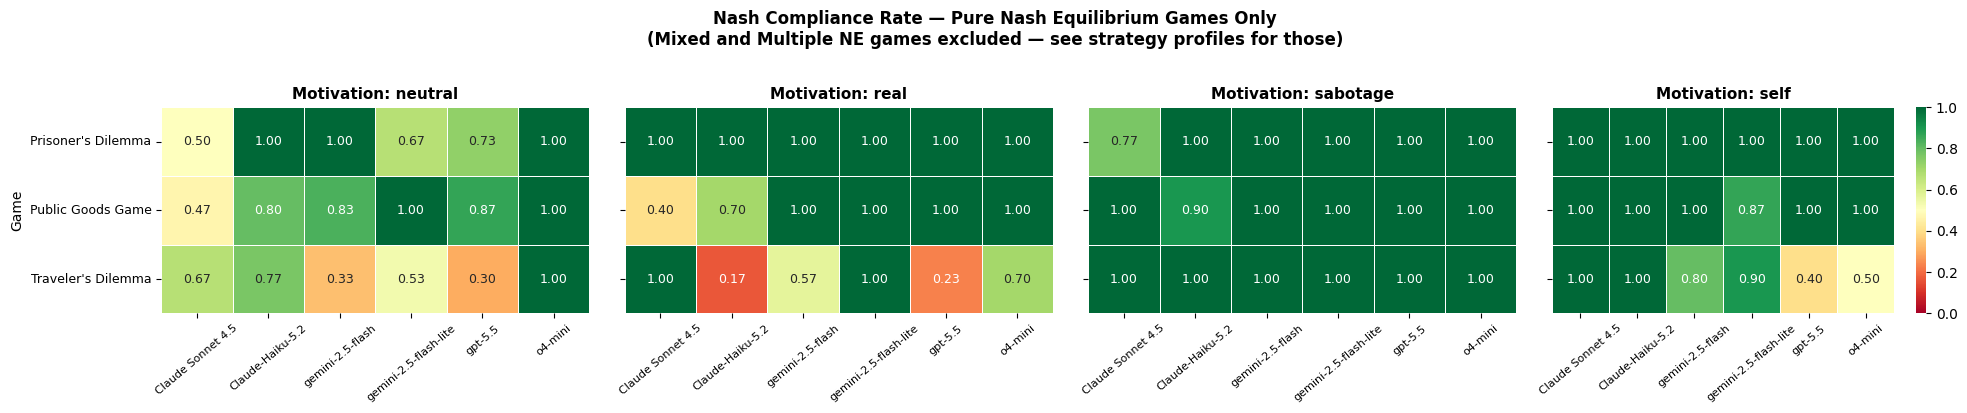

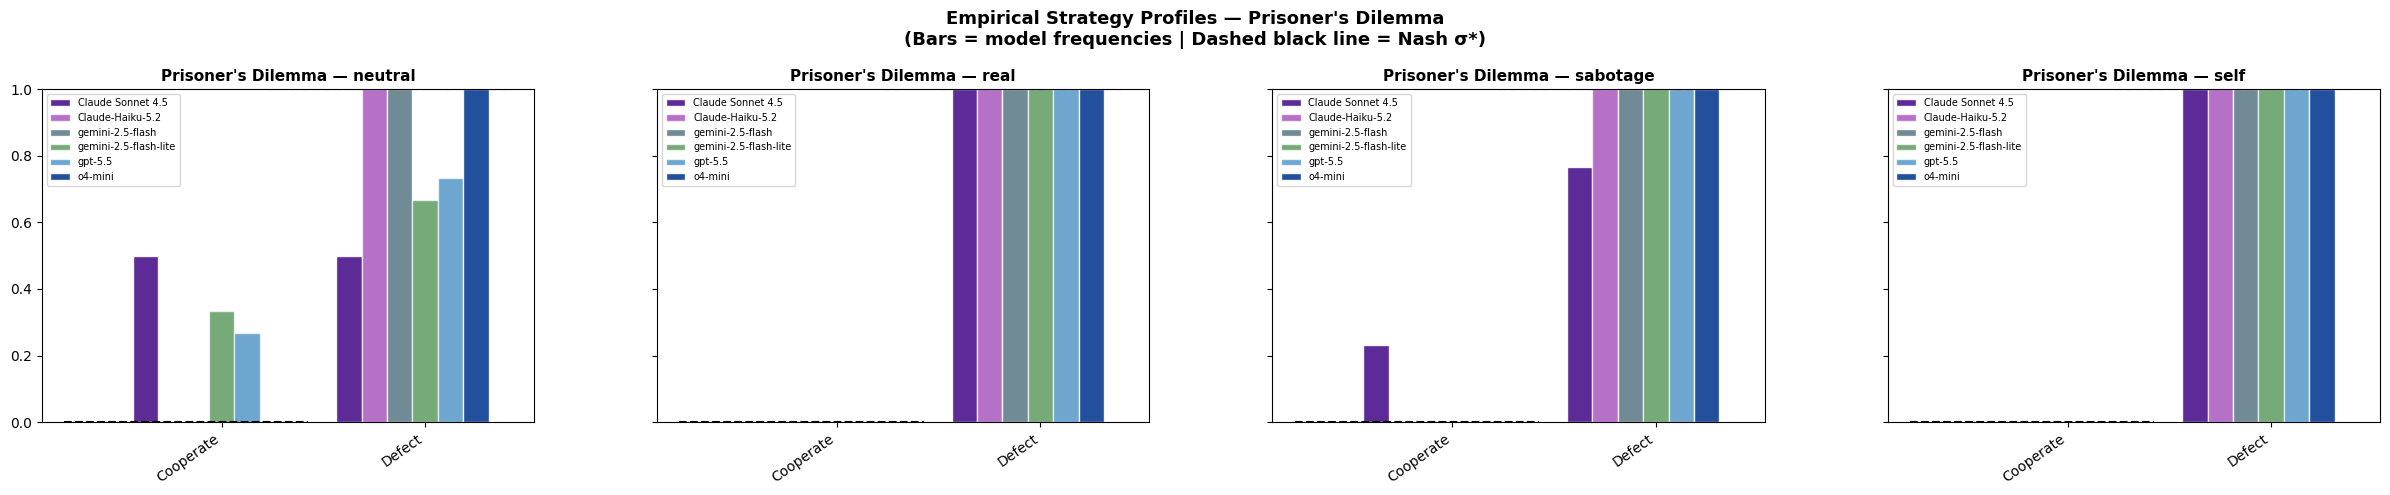

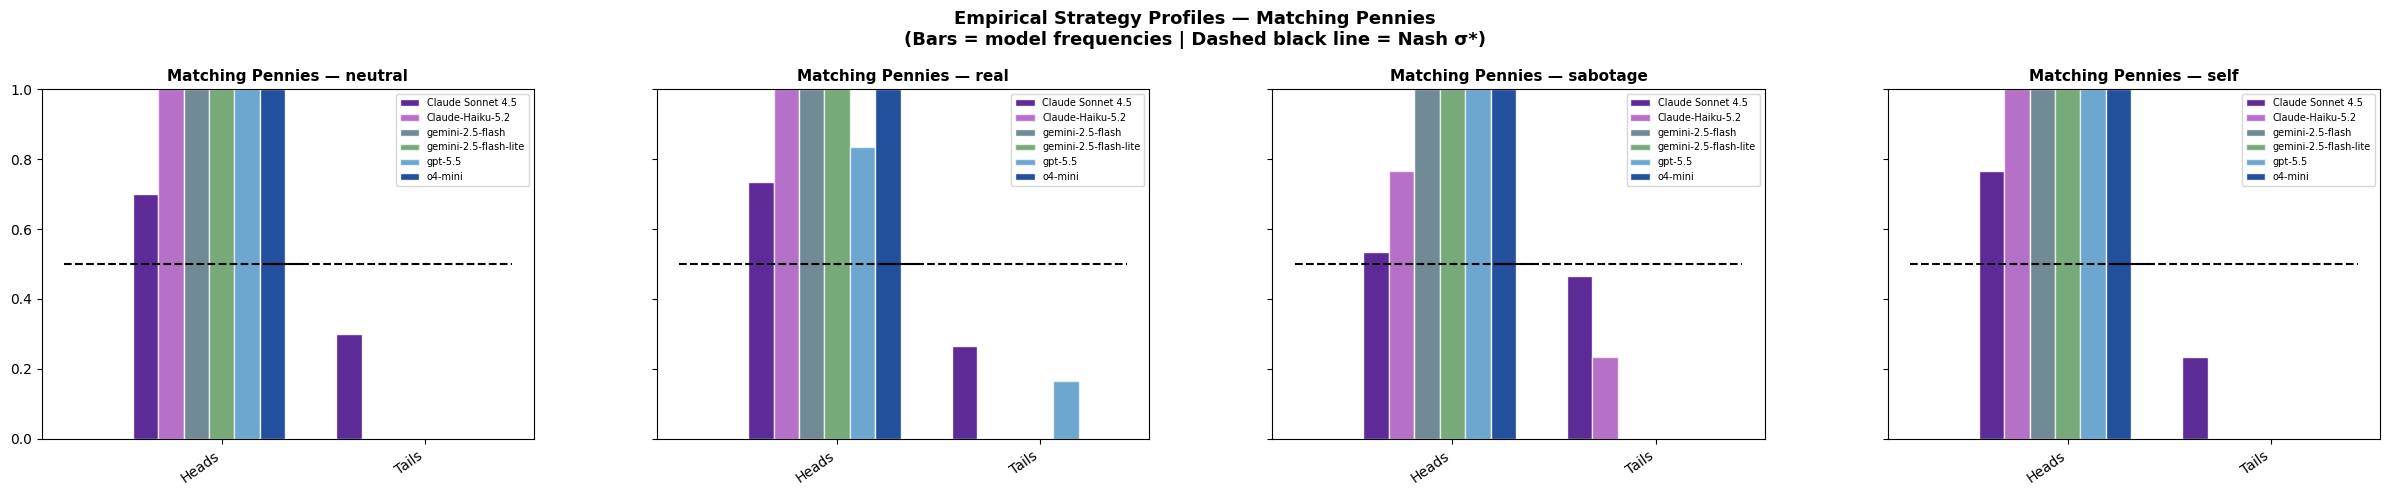

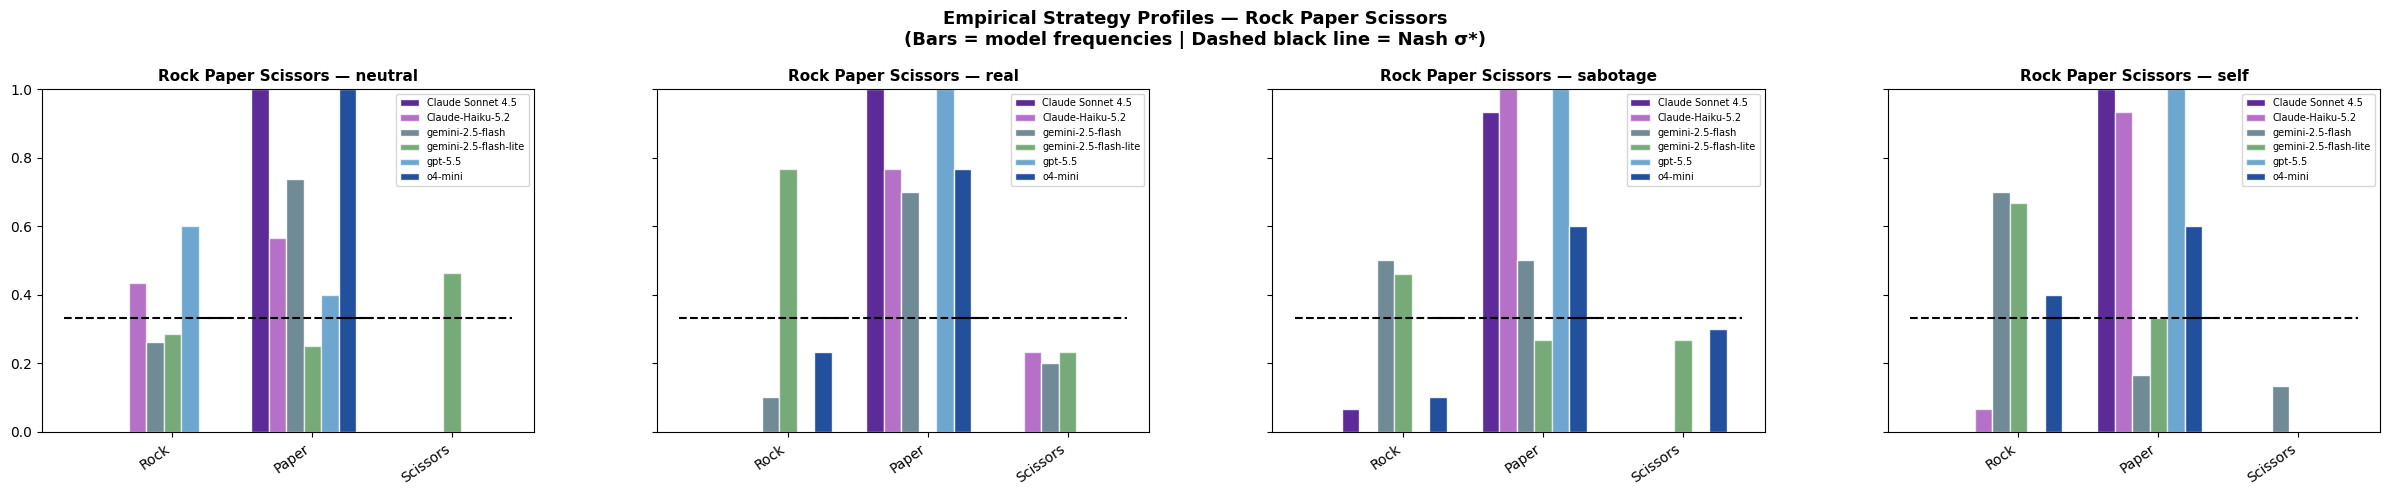

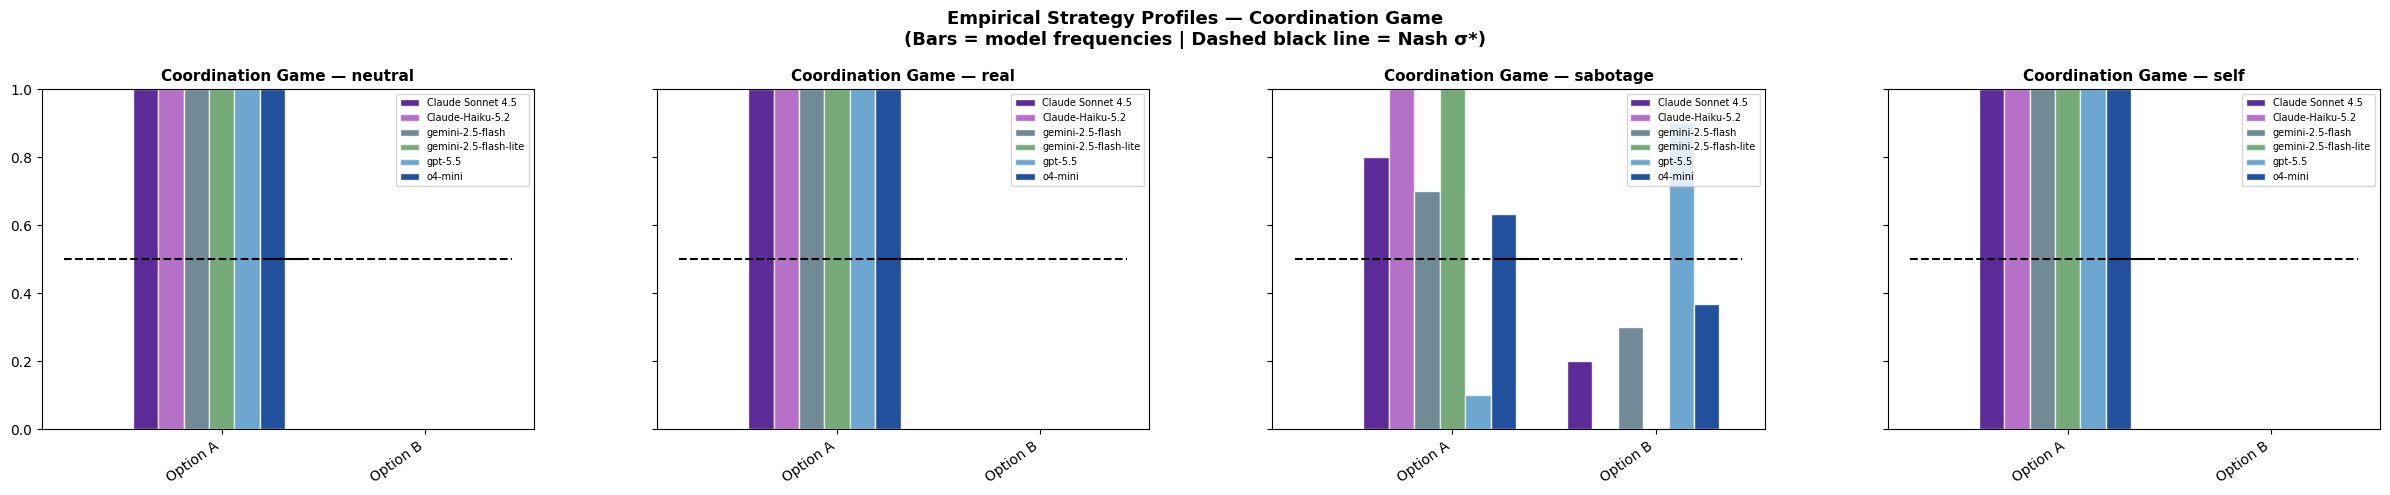

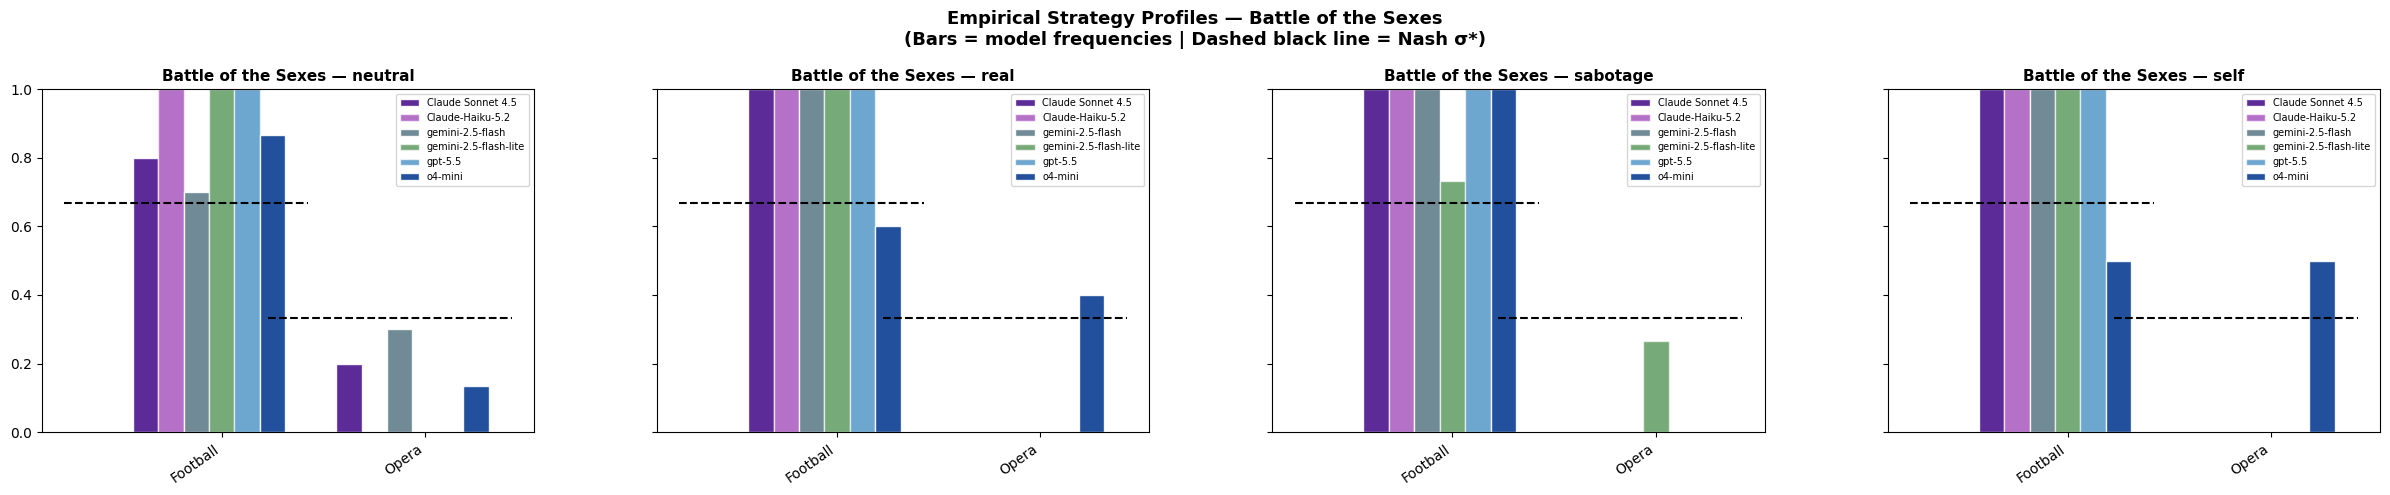

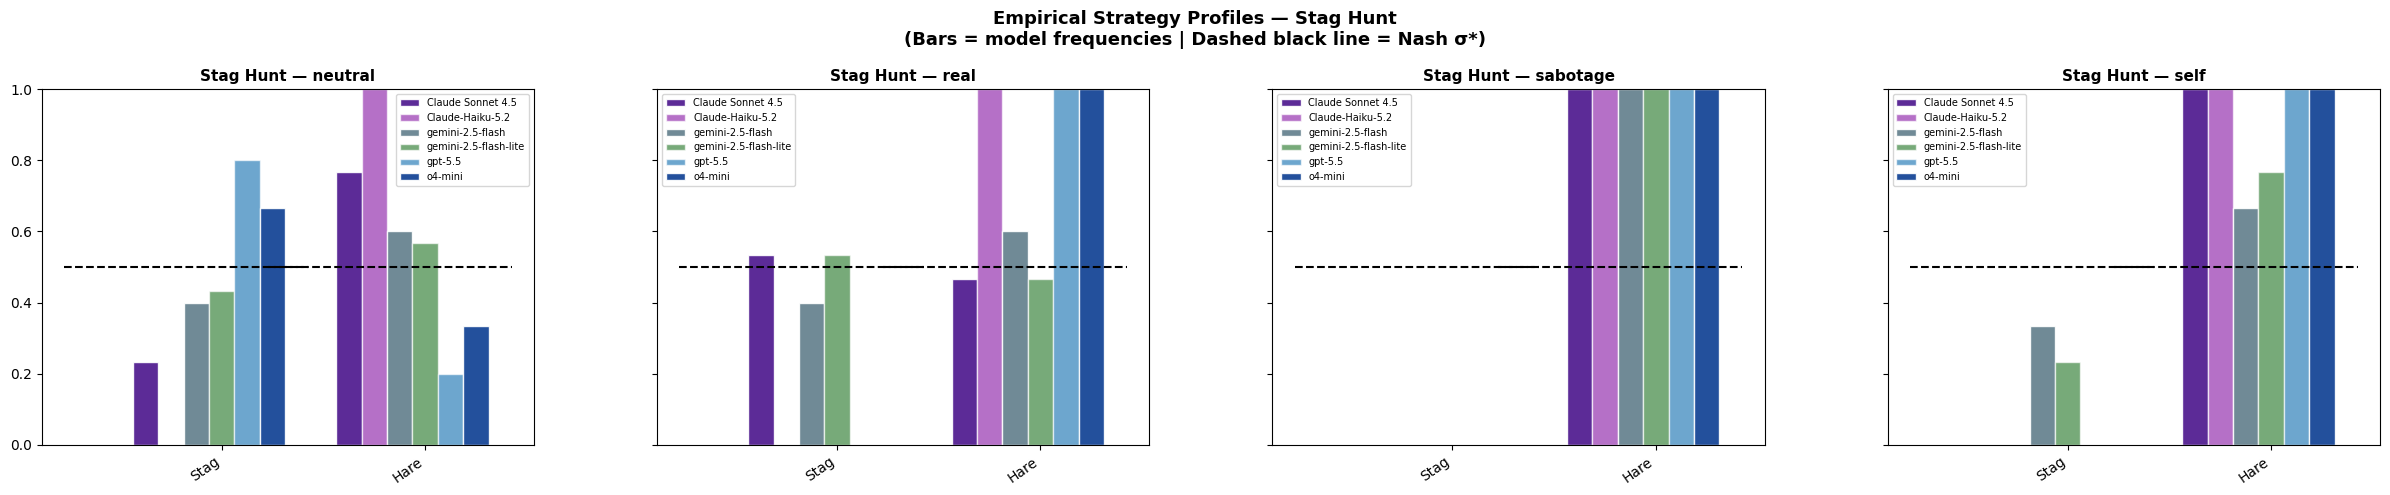

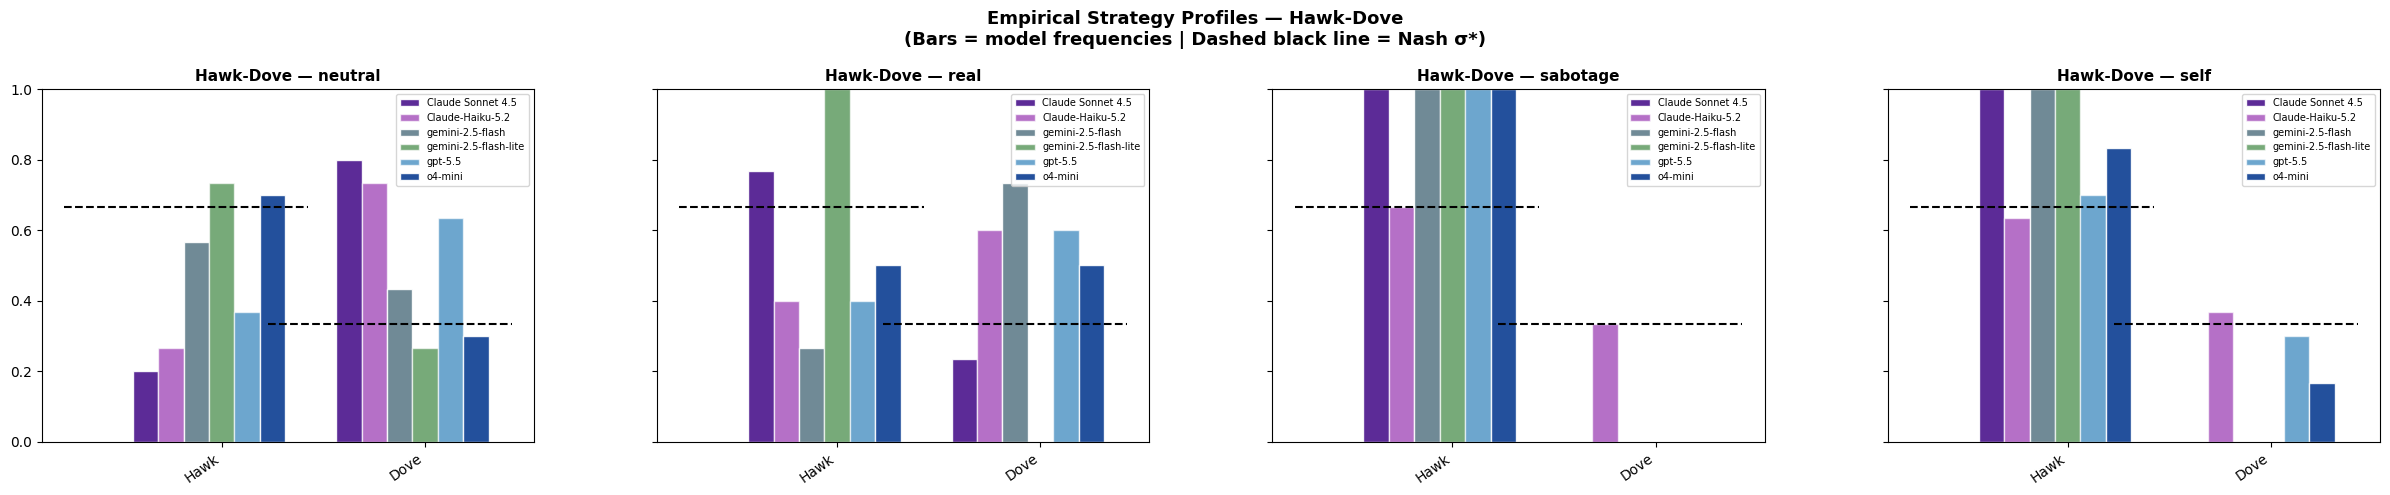

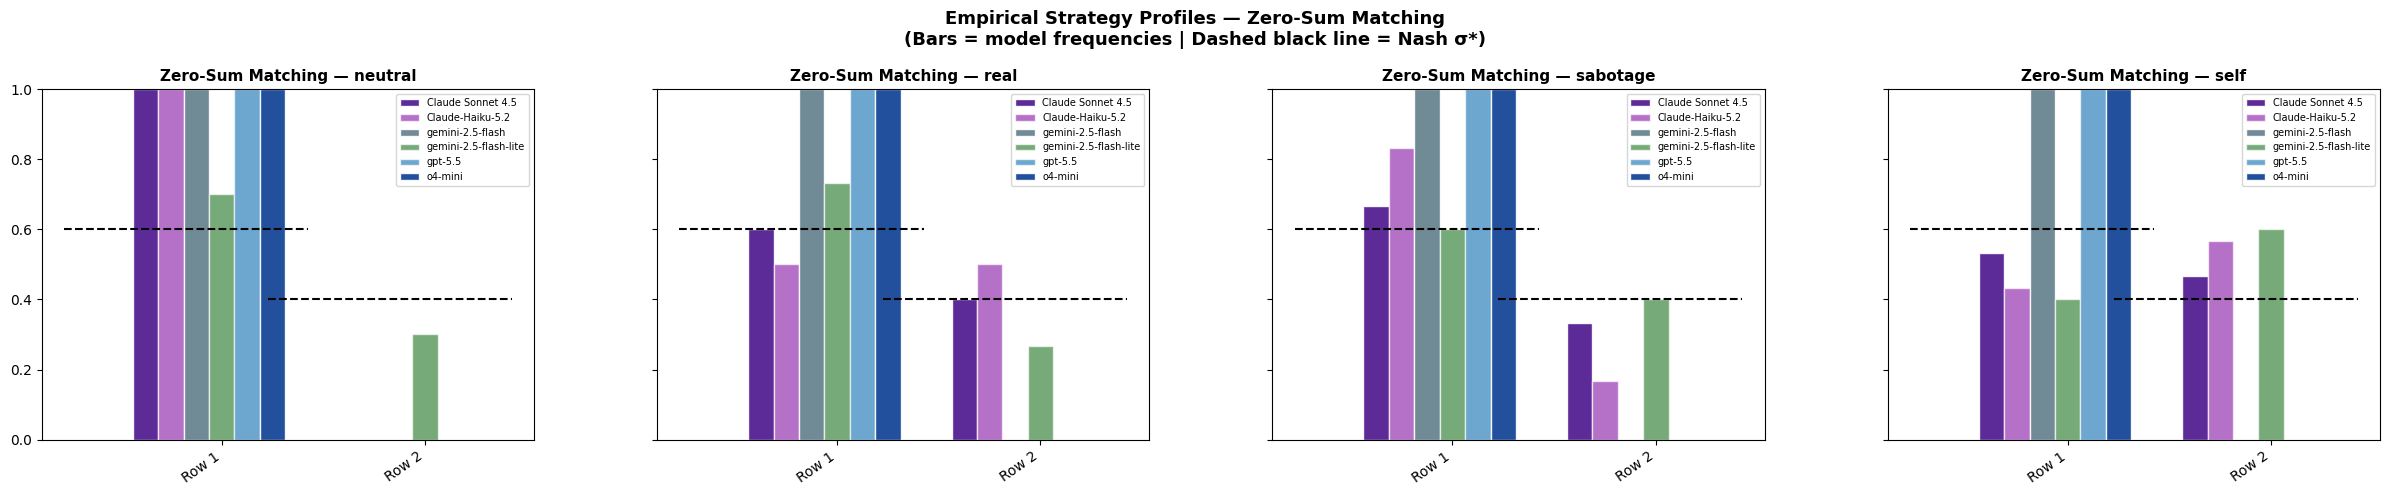

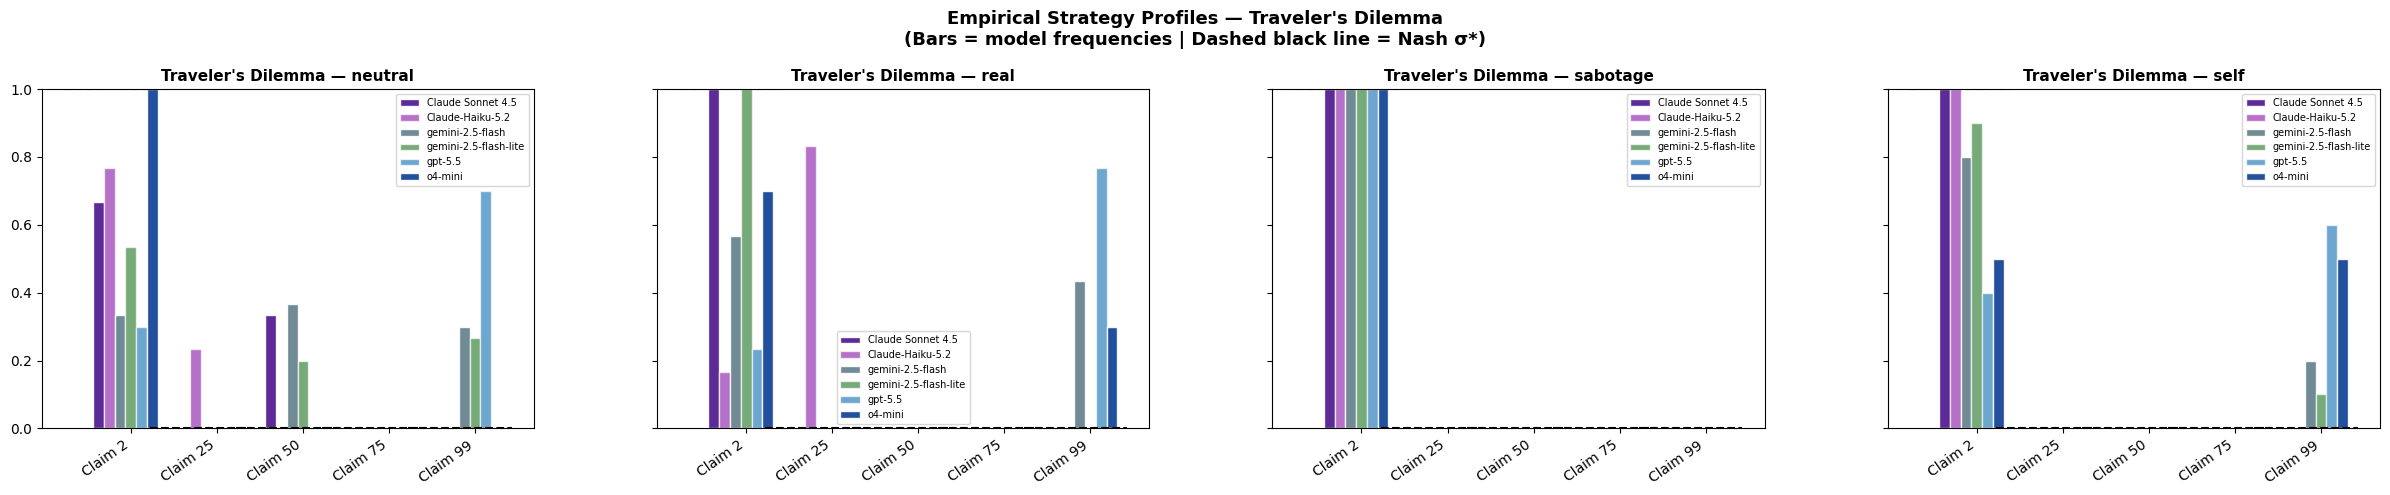

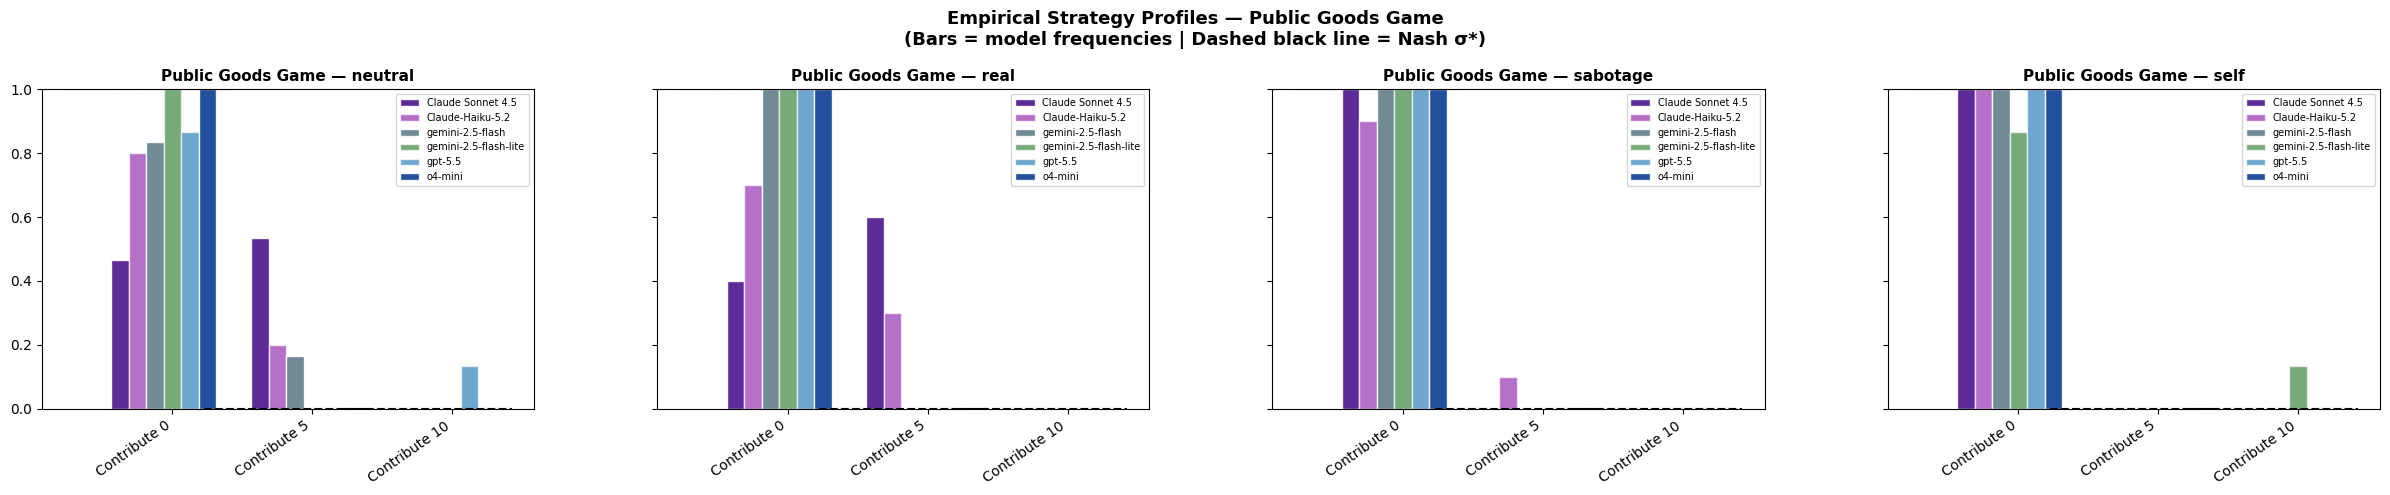

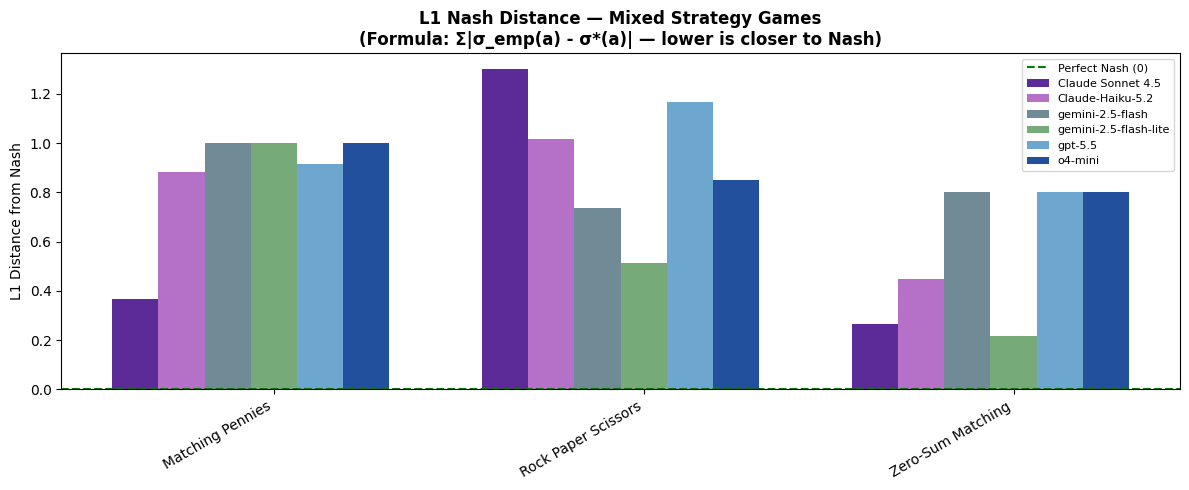

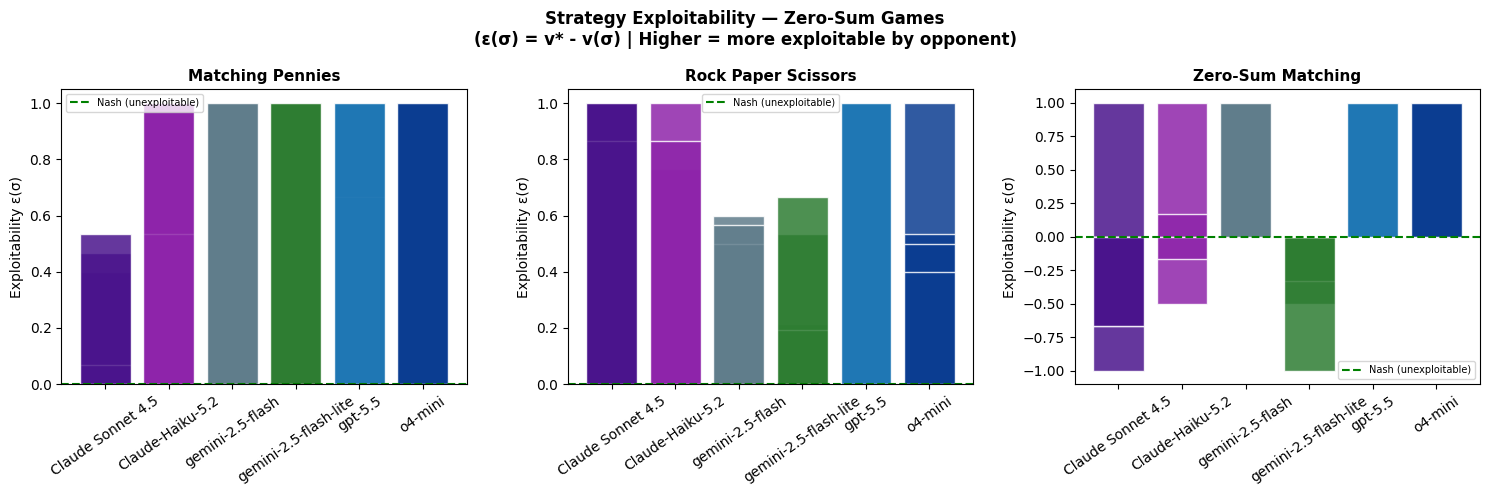

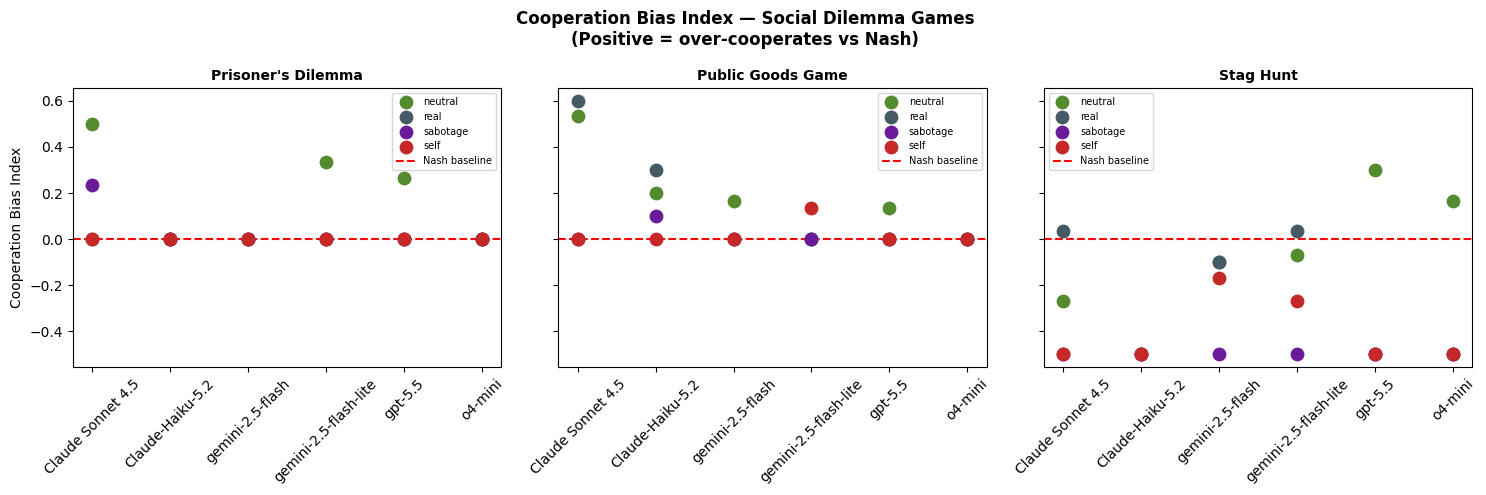

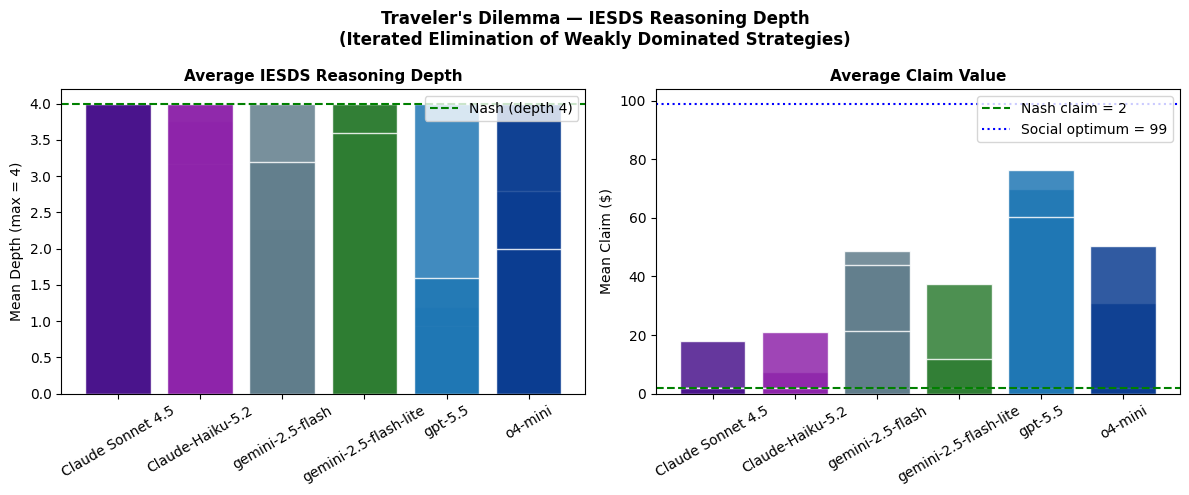

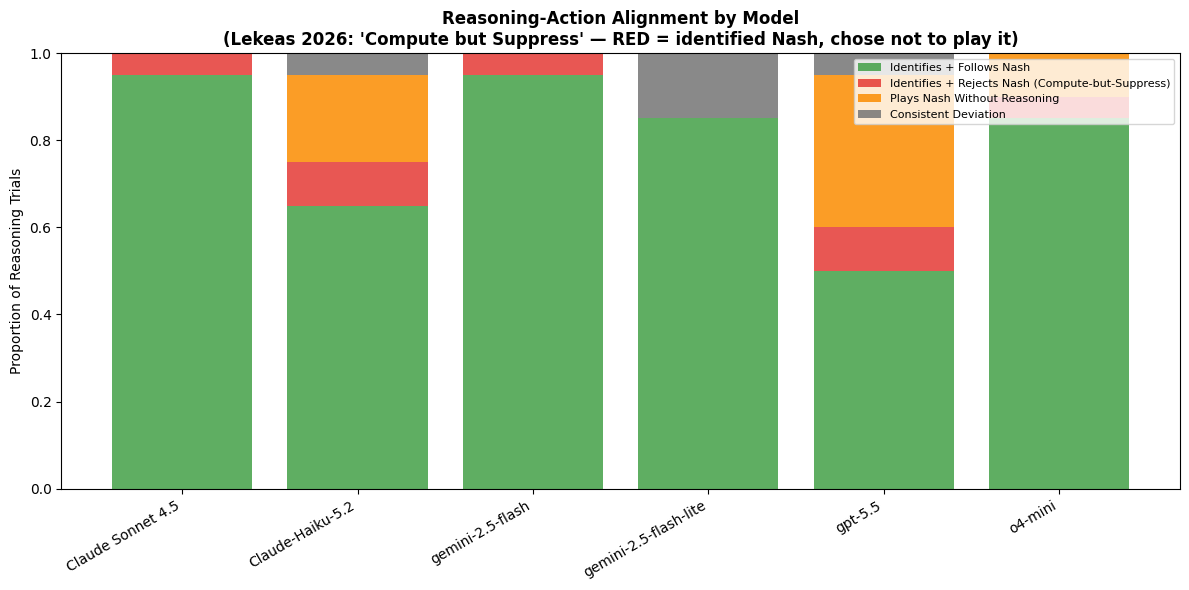

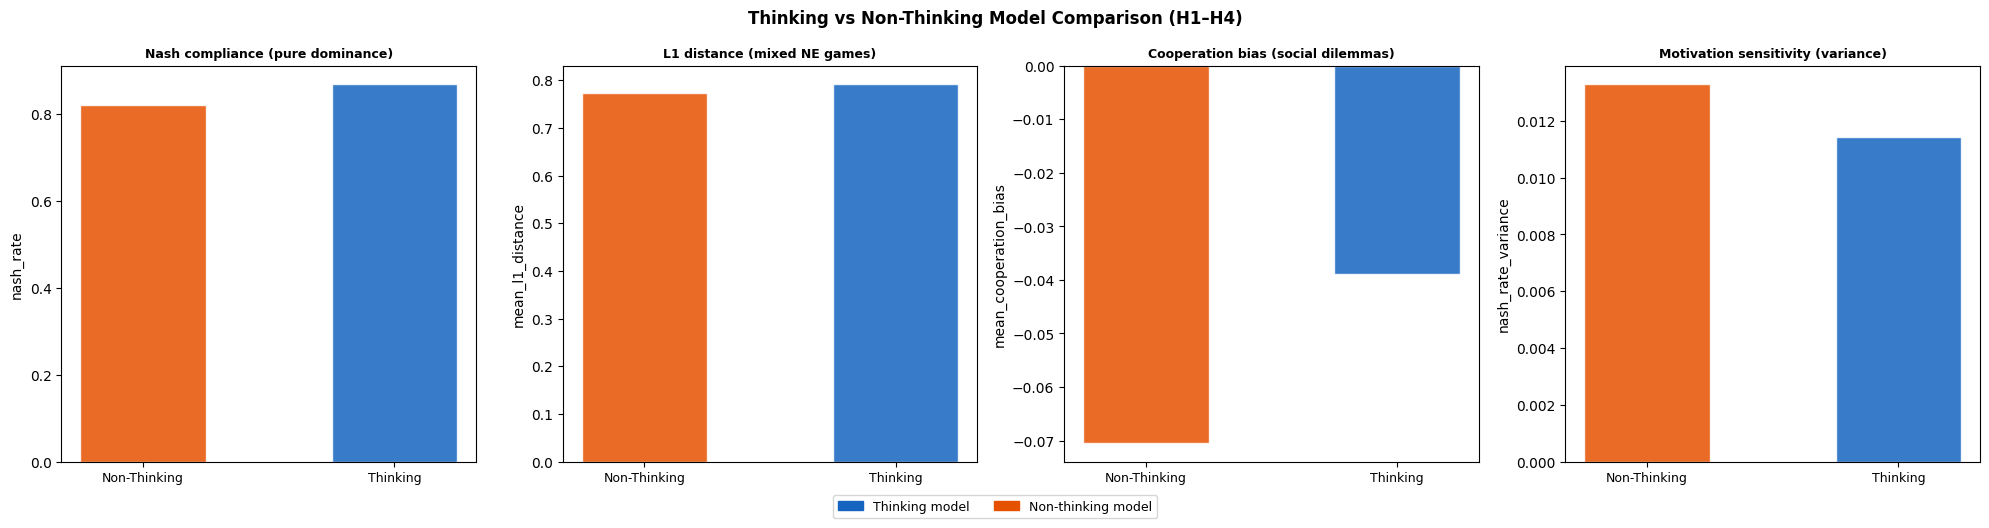

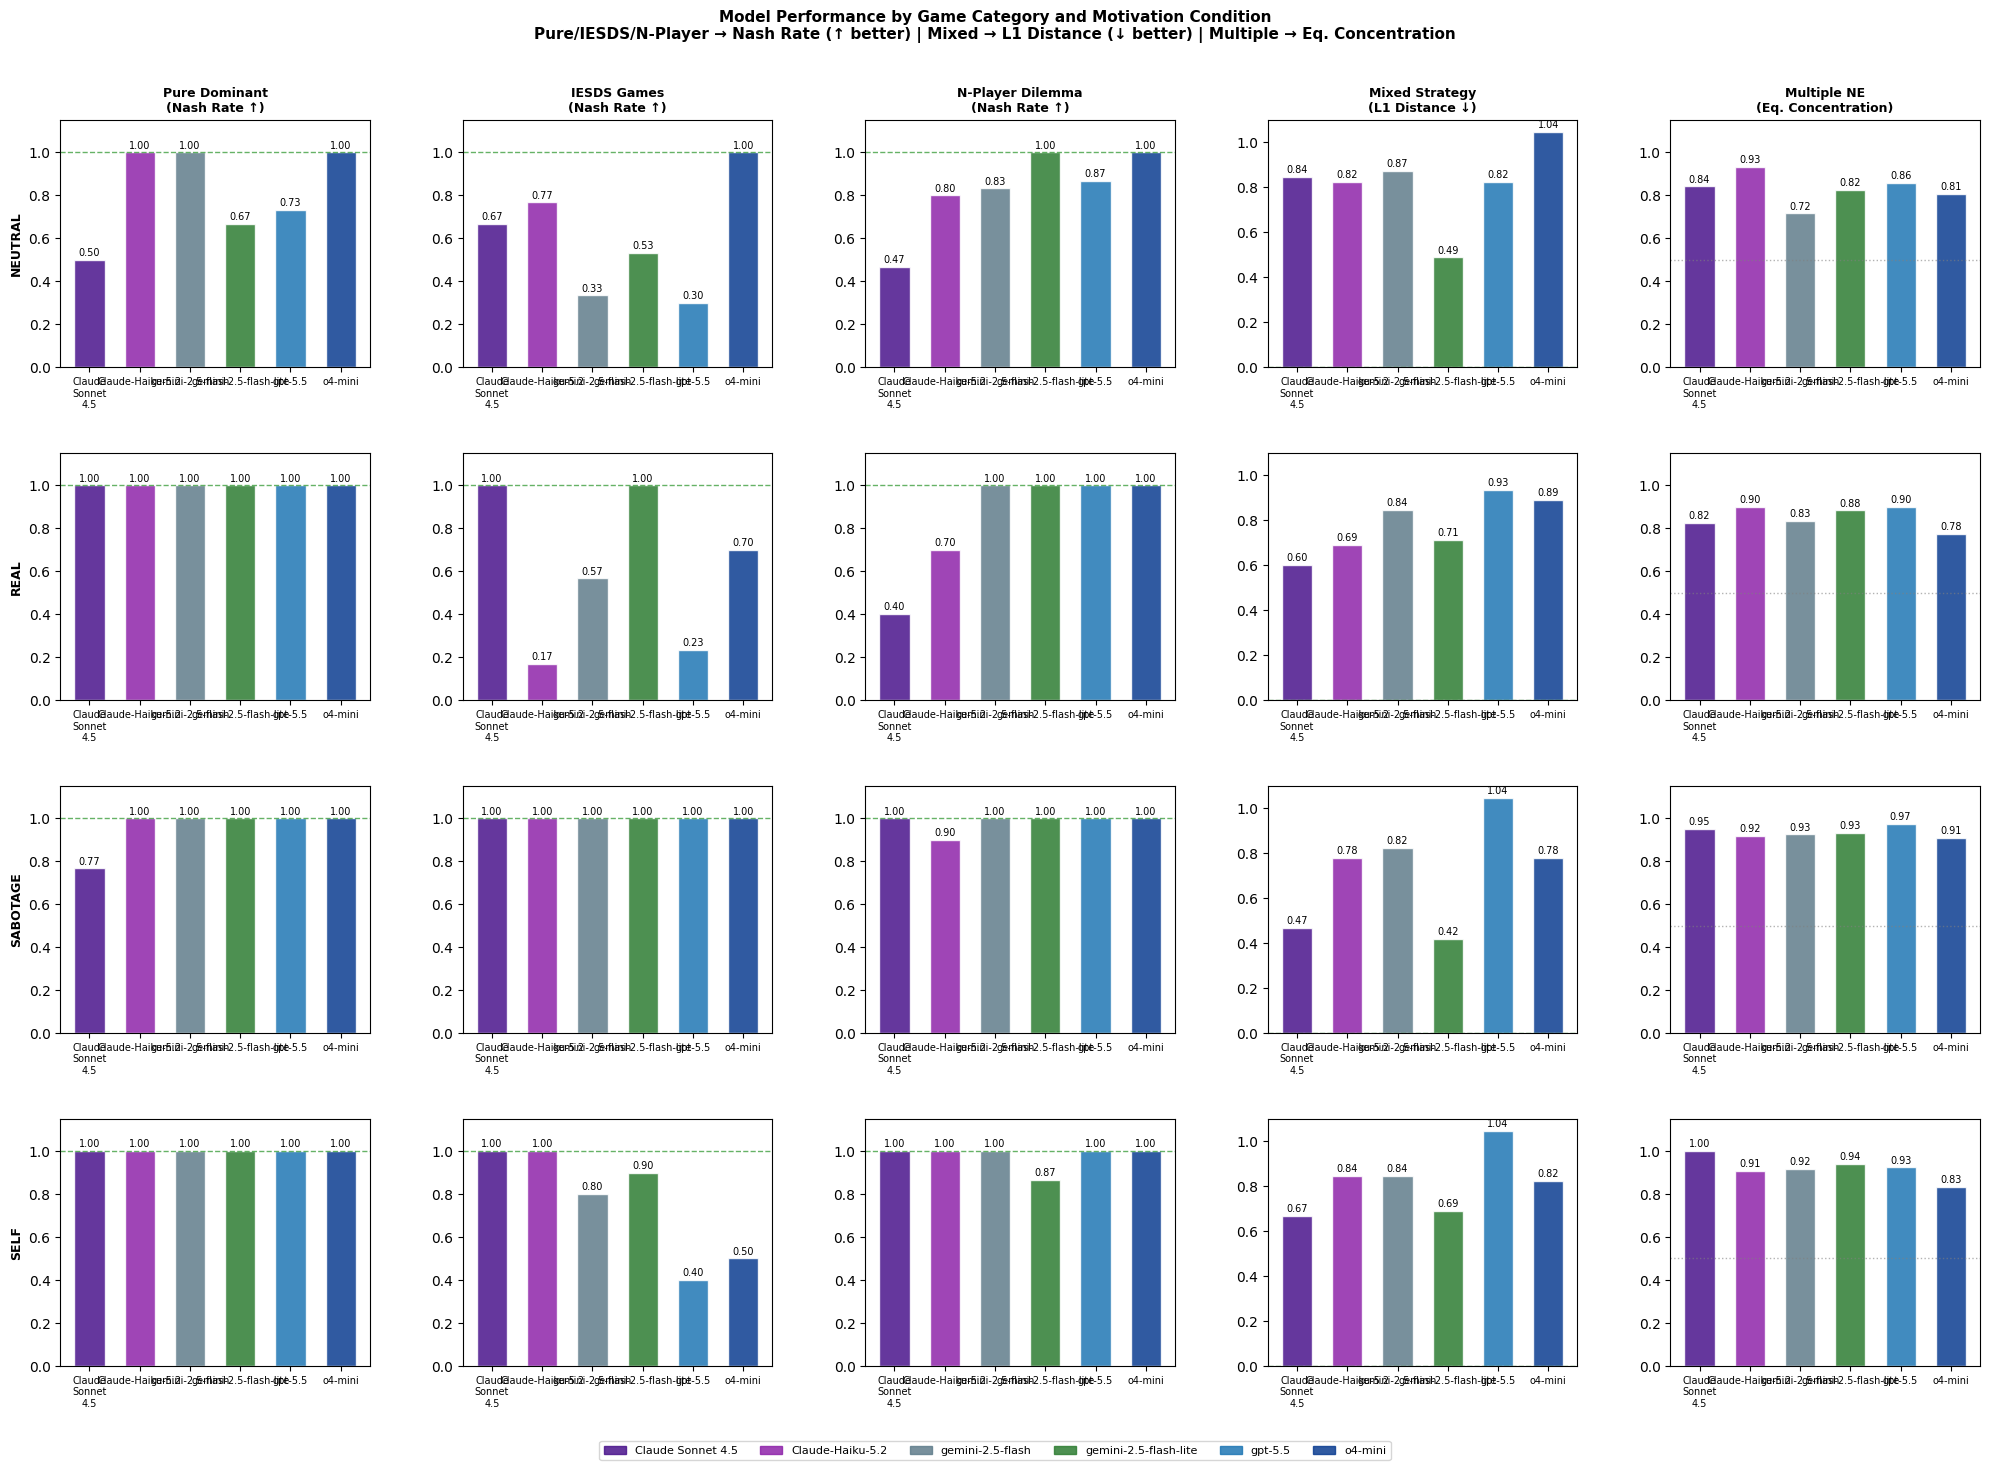


  ANALYSIS COMPLETE
  All outputs saved to: /content/drive/MyDrive/LLM_Nash_Experiment/

  MODEL: Claude Sonnet 4.5  (Claude — Thinking Model)

  ▶ Pure Dominant Strategy Games
    Context: Nash via strict dominance (Lecture 4). Nash rate = dominant strategy frequency.
    Games:   Prisoner's Dilemma

    [NEUTRAL]  n=30 trials
      Nash rate:           0.500  (moderate deviation)
      EU loss:             0.5000  (loses 0.500 utility vs Nash)
      L1 Nash distance:    nan  (strong deviation)
      Exploitability:      nan  (highly exploitable)
      Maxmin gap:          nan  (nan below Nash minimum)
      Cooperation bias:    0.5000  (over-cooperates by 0.500)
      IESDS depth:         nan/4  (nan/4 rounds performed)
      Eq. concentration:   nan  (no clear focal point)
      Risk-dominant (Hare):   nan  |  Payoff-dominant (Stag): nan

    [REAL]  n=30 trials
      Nash rate:           1.000  (≈ Nash)
      EU loss:             0.0000  (no utility loss)
      L1 Nash distance:  

In [ ]:
# ── Run Everything ───────────────────────────────────
# Uncomment and run after loading data in Cell 5.

df        = load_all_data(MODEL_FILES)
df_reason = load_reasoning_data(REASONING_FILES)
results   = run_full_analysis(df, df_reason, save_dir=DATA_DIR)